# AM 115 Group Project 2 - Analysis of Airport Security with Queuing Theory
By Kaylee Vo, Tadhg Scannell

## Parameter Estimation for M/M/c Priority Queue Model

In [1]:
import heapq
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.special as sp
import seaborn as sns
from scipy.optimize import basinhopping, minimize, minimize_scalar
from scipy.special import factorial

In [2]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"

# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

### EDA

In [3]:
df = pd.read_csv("lax_passengers.csv")

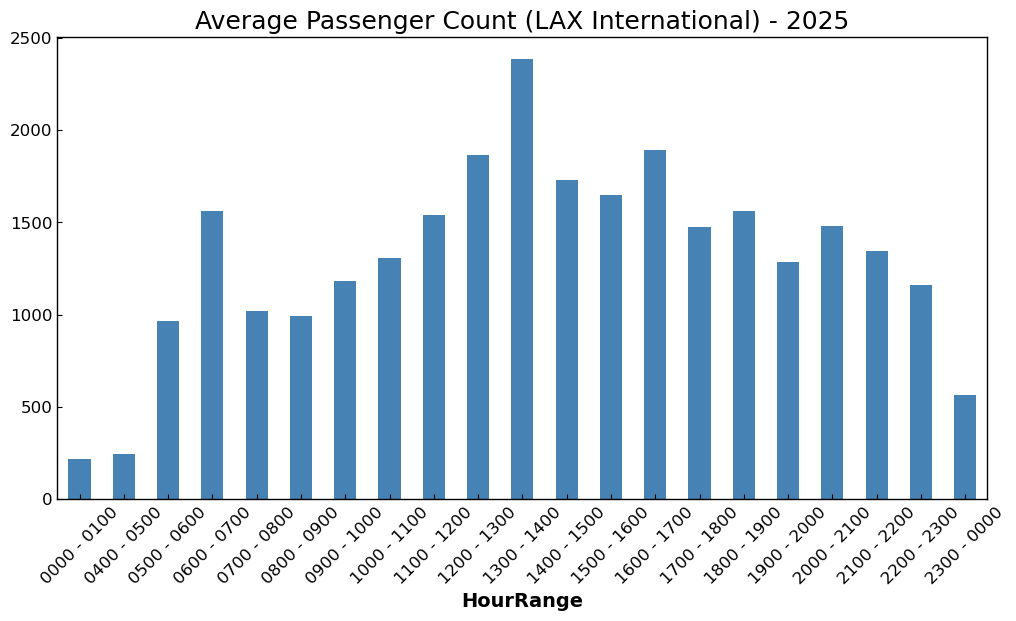

In [4]:
df.groupby("HourRange")["TotalPassengerCount"].mean().plot(
    kind="bar", figsize=(12, 6), color="steelblue"
)

plt.title("Average Passenger Count (LAX International) - 2025", fontsize=18)
plt.xticks(rotation=45)
plt.show()

### Arrival Rate ($\hat{\lambda}$) via MLE 

In [5]:
total_hours = df.shape[0]

total_passengers = df["TotalPassengerCount"].sum()
# lambda constant is
lambda_constant = total_passengers / total_hours
lambda_hat = lambda_constant / 60

print("Passengers per Day {:.2f}".format(lambda_constant * 24))
print("Lambda Estiimate: {:.2f} passengers per minute".format(lambda_hat))

Passengers per Day 33987.54
Lambda Estiimate: 23.60 passengers per minute


- The MLE estimate for the Poisson distribution parameter is just the average of the data.
- Our estimate of the arrival rate is $\hat{\lambda} = 23.6$ passengers per hour.
- We can plug this into our exponential distribution to get a distribution for interarrival times.
- Source
    - https://awt.cbp.gov/Report

### Service Time Approximation ($\hat{\mu}$)

The idea of using Erlang’s C formula along with Litte’s Law is that we use the average wait time and arrival rate to back out the service rate $\mu$ numerically. We find the value of $\mu$ such that the theoretical average wait time $W_q$ matches the observed average wait time $W_q^{obs}$. 

Assume
- We have to assume the data recorded by the TSA is from an M/M/c queue. 
- This means that passport control lines are Poisson arrivals, exponential interarrival times, exponential service times, and $c$ servers.
- Passport control vs security lines are not one-to-one, but we have to use the data given.


In [6]:
Wq_est = df["AverageWait"].mean()
print("Estimated Average Wait Time: {:.2f} minutes".format(Wq_est))

Estimated Average Wait Time: 25.70 minutes


In [7]:
# Parameters
# arrival rate (passengers per minute)
lam = lambda_hat
# average wait time in minutes
Wq_target = Wq_est
# number of servers
c = 12

- We set `lam` to our observed estimate of the arrival rate ($\hat{\lambda}$).
- We set `Wq_target` to the observed average wait time in minutes.
- We set the number of servers $c$ to be 12. This is the maximum number of servers that we computed from the Lockheed 
Martin data.

In [8]:
def erlang_c(c, rho):
    """implements Equation (1) below

    Args:
        c (_type_): number of servers
        rho (_type_): lambda / (c * mu), where mu is the service rate
    """
    # system unstable,
    # keep because I kept getting NaN errors
    if rho >= 1:
        return 1.0
    # Erlang C formula
    # See equation below
    numer = (rho * c) ** c / (sp.factorial(c) * (1 - rho))
    denom = sum((rho * c) ** n / sp.factorial(n) for n in range(c)) + numer
    return numer / denom


def wait_time(mu):
    if mu <= lam / c:  # system unstable
        return 1e6
    # server utilization
    rho = lam / (c * mu)
    C = erlang_c(c, rho)

    # Wait time in queue
    Wq = C / (c * mu - lam)

    # Minimize the difference between theoretical Wq and observed
    return abs(Wq - Wq_target)


# Wq is the average wait time in queue
res = minimize_scalar(wait_time, bounds=(lam / c + 0.001, 2), method="bounded")

if res.success:
    mu_est = res.x
    print(f"Estimated service rate μ: {mu_est:.2f} passengers/min")
    print(f"Estimated service time: {1 / mu_est:.2f} minutes/passenger")
else:
    print("Optimization failed.")

Estimated service rate μ: 1.97 passengers/min
Estimated service time: 0.51 minutes/passenger


#### Equations

**Equation 1**: Erlang's C

Let $\rho = \frac{\lambda}{c \mu}$, the server utilization. The Erlang-C formula gives us the probability that an arriving customer is forced to join the queue (all servers are occupied), which is given by:

$$
C(c, p) = \frac{(\frac{(c \rho)^c}{c!}) (\frac{1}{1-\rho})}{\sum_{k=0}^{c-1} \frac{(c \rho)^k}{k!} + \frac{(c \rho)^c}{c! (1 - \rho)}}
$$


**Equation 2**: 

The average number of customers in the system is given by 

$$
L = L_q + L_s
$$

where $L_q$ is the average number of customers in the queue and $L_s$ is the average number of customers in service.
Little's Law

$$
L = \lambda W
$$
- L: the average number of customers in the system
- $\lambda$: the arrival rate
- $W$: the average time a customer spends in the system
- This tells us that the long-term average number of customers in a stable system is equal to the long-term average arrival rate multiplied by the long-term average time a customer spends in the system.
- Formula works for subsystems as well, such as the queue.

$$
W_q = \frac{L_q}{\lambda} = \frac{C(c, \rho)}{c\mu - \lambda}
$$


Sources
- https://en.wikipedia.org/wiki/M/M/c_queue
- https://en.wikipedia.org/wiki/Little%27s_law

### Number of Servers Estimation ($c$)

In [9]:
def calc_and_print_num_servers(df, title=""):
    # Make the assumption that half of staff are allocated to
    # security screening, hence the division by 2
    df["tsa_per_lane"] = df["Staff"] / df["Lanes"] / 2
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    mean_weekday = df["tsa_per_lane"].mean()
    min_weekday = df["tsa_per_lane"].min()
    max_weekday = df["tsa_per_lane"].max()

    print(f"{title} Staffing Statistics")
    print(f"  Mean TSA per lane: {mean_weekday:.2f}")
    print(f"  Min TSA per lane: {min_weekday:.2f}")
    print(f"  Max TSA per lane: {max_weekday:.2f}")

In [10]:
calc_and_print_num_servers(pd.read_csv("./lockheed_staff_weekday.csv"), title="Weekday")
calc_and_print_num_servers(pd.read_csv("./lockheed_staff_weekend.csv"), title="Weekend")

Weekday Staffing Statistics
  Mean TSA per lane: 4.50
  Min TSA per lane: 2.50
  Max TSA per lane: 11.67
Weekend Staffing Statistics
  Mean TSA per lane: 4.52
  Min TSA per lane: 2.69
  Max TSA per lane: 12.00


- It is very unclear what Lockheed Martin's data means when they mention staff and lines.
- The data seems like it's for the entire airport, not just a specific terminal.
- The size of the airport is also not clear.
- From anecdotal experience, the number of servers at a security checkpoint is around 4-5, with around 3 points of entry. The max of 12 servers from above seems to be a reasonable estimate.


## M/M/c Priority Queue Model

### Version 1

- This baseline model is an M/M/c queue, where c is the number of servers.
- The servers are shared between regular and TSA PreCheck passengers. Pooled servers.
- This is not parallel. There is no closed-form solution for this model.

Distribution Assumptions

The interarrival times of the passengers are exponentially distributed with a mean of $\frac{1}{\lambda}$, where $\lambda$ is the arrival rate of passengers. The pdf is given by:

$$
a(t) =
\begin{cases}
  \lambda e^{-\lambda t} & \text{if } t \geq 0 \\
  0 & \text{if } t < 0
\end{cases}
$$

Interarrival times can be interpreted as "how long do I wait until the next person arrives?".

As for the service times, we also assume they are exponentially distributed, where $\mu$ is the service rate of the servers. The mean service time is $\frac{1}{\mu}$. The pdf is given by:

$$
b(t) =
\begin{cases}
  \mu e^{-\mu t} & \text{if } t \geq 0 \\
  0 & \text{if } t < 0
\end{cases}
$$

Memoryless Property

The exponential distribution is the only continuous distribution with the memoryless property. Other distributions in the exponential family do not have this property. This means that the probability of waiting an additional time $t$ is independent of how long you have already waited.

$$
P(X > s + t | X > s) = P(X > t) \quad \forall s, t \geq 0
$$

In reality, this assumption is quite strong for service times because if service time has already been long, it is likely to be longer (i.e. dealing with a complex issue or unruly passenger). We'll relax this assumption later.



In [11]:
# Units are passengers per minute
ARRIVAL_RATE = 23.6
print("Arrival Rate: {:.2f} passengers/min".format(ARRIVAL_RATE))

Arrival Rate: 23.60 passengers/min


In [12]:
# These are lower bounds
# Service rate for regular passengers, units are passengers per minute
SERVICE_RATE_REGULAR = round(mu_est, 4)
# Faster service rate for TSA PreCheck
SERVICE_RATE_PRECHECK = SERVICE_RATE_REGULAR * 1.33


print("Service Rate (Regular): {:.2f} passengers/min".format(SERVICE_RATE_REGULAR))
print(
    "Service Rate (TSA PreCheck): {:.2f} passengers/min".format(SERVICE_RATE_PRECHECK)
)

Service Rate (Regular): 1.97 passengers/min
Service Rate (TSA PreCheck): 2.62 passengers/min


- For service rate, we assume it encompasses the process from ID and boarding pass check to the end of the screening process, where one picks up their bags at the end of the conveyor belt.
- Sources below provide a lower bound on service time. For regular, it is 30 minutes per passenger, for TSA PreCheck, it's 19 minutes per passenger.
- TSA is quicker by 33%
- Sensitivity analysis on this. Keep the 1.33 factor.

Sources
- https://www.gao.gov/assets/gao-18-236.pdf

In [13]:
PRECHECK_PROB = 0.27  # Probability of being PreCheck

Sources
- https://www.gao.gov/assets/gao-18-236.pdf
    - "average of 27% of passengers use TSA PreCheck"
- https://www.washingtonpost.com/travel/2024/11/28/tsa-precheck-vs-standard-security-line/
- https://www.yahoo.com/news/reached-peak-precheck-233857724.html

In [14]:
NUM_SERVERS = 12

- Estimate from empirical data
- Use a range from Lockheed Martin data.

- https://www.trb.org/publications/circulars/ec060/06_Bradley.pdf
    - The data is noisy and doesn't have exact data on the number of TSA screeners, just staff
    - We assume that half of the staff are TSA PreCheck screeners
    - This gives us an average of 4.5 TSA PreCheck screeners, with a range of 2 to 12 across a whole day.


In [15]:
# 33987.54375
MAX_CUST = round(lambda_constant * 24, -3)
print("Maximum Passengers per Day: {:.2f}".format(MAX_CUST))

Maximum Passengers per Day: 34000.00


- Estimated from LAX data

In [16]:
rho_reg = ARRIVAL_RATE / (NUM_SERVERS * SERVICE_RATE_REGULAR)
rho_pre = ARRIVAL_RATE / (NUM_SERVERS * SERVICE_RATE_PRECHECK)

print(f"rho_reg: {rho_reg:.4f}, rho_pre: {rho_pre:.4f}")
print("Stability Check:")
print(f"   rho_reg < 1: {rho_reg < 1}, rho_pre < 1: {rho_pre < 1}")

rho_reg: 0.9983, rho_pre: 0.7506
Stability Check:
   rho_reg < 1: True, rho_pre < 1: True


### Simulation Functions

In [17]:
# random.seed(42)  # For reproducibility

In [18]:
def record_wait_time(
    wait_time, is_precheck, wait_times_precheck, wait_times_regular, cid
):
    """Record wait time in appropriate list"""
    if is_precheck:
        wait_times_precheck[cid] = wait_time
    else:
        wait_times_regular[cid] = wait_time

In [19]:
def get_service_time(is_precheck, service_rate_precheck, service_rate_regular):
    """Generate service time based on customer type"""
    service_rate = service_rate_precheck if is_precheck else service_rate_regular
    return random.expovariate(service_rate)

In [20]:
def find_available_servers(servers_busy_until, current_time):
    """Find all available servers"""
    return [i for i, t in enumerate(servers_busy_until) if t <= current_time]

In [21]:
def assign_to_server_or_queue(
    servers_busy_until,
    current_time,
    is_precheck,
    service_rate_precheck,
    service_rate_regular,
    event_queue,
    cid,
    waiting_queue,
    priority,
    wait_times_precheck,
    wait_times_regular,
):
    """Assign customer to available server or add to waiting queue"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    if available_servers:
        server = available_servers[0]
        service_time = get_service_time(
            is_precheck, service_rate_precheck, service_rate_regular
        )
        servers_busy_until[server] = current_time + service_time

        record_wait_time(0.0, is_precheck, wait_times_precheck, wait_times_regular, cid)

        heapq.heappush(event_queue, (current_time + service_time, "departure", cid))
    else:
        heapq.heappush(waiting_queue, (priority, current_time, cid, is_precheck))

In [22]:
def handle_arrival_event(
    event_queue,
    current_time,
    cid,
    customer_id,
    arrival_rate,
    precheck_probability,
    servers_busy_until,
    service_rate_precheck,
    service_rate_regular,
    waiting_queue,
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
):
    """Process a customer arrival event"""

    # Schedule next arrival
    inter_arrival = random.expovariate(arrival_rate)
    heapq.heappush(event_queue, (current_time + inter_arrival, "arrival", customer_id))

    # Determine if PreCheck or regular
    is_precheck = random.random() < precheck_probability
    priority = 0 if is_precheck else 1

    # Record arrival time
    if is_precheck:
        arrival_times_precheck[cid] = current_time
    else:
        arrival_times_regular[cid] = current_time

    # Try to assign to server
    assign_to_server_or_queue(
        servers_busy_until,
        current_time,
        is_precheck,
        service_rate_precheck,
        service_rate_regular,
        event_queue,
        cid,
        waiting_queue,
        priority,
        wait_times_precheck,
        wait_times_regular,
    )

    return customer_id + 1

In [23]:
def handle_departure_event(
    event_queue,
    current_time,
    servers_busy_until,
    waiting_queue,
    service_rate_precheck,
    service_rate_regular,
    wait_times_precheck,
    wait_times_regular,
):
    """Process a server departure event"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    for server in available_servers:
        if waiting_queue:
            priority, arrival_time, queued_cid, is_precheck = heapq.heappop(
                waiting_queue
            )
            service_time = get_service_time(
                is_precheck, service_rate_precheck, service_rate_regular
            )
            servers_busy_until[server] = current_time + service_time

            wait_time = current_time - arrival_time
            record_wait_time(
                wait_time,
                is_precheck,
                wait_times_precheck,
                wait_times_regular,
                queued_cid,
            )

            heapq.heappush(
                event_queue, (current_time + service_time, "departure", queued_cid)
            )

In [24]:
random.seed(115)


def run_simulation(
    max_cust,
    arrival_rate,
    precheck_probability,
    service_rate_precheck,
    service_rate_regular,
    num_servers,
):
    """Main simulation function"""
    # System State
    event_queue = []
    waiting_queue = []
    servers_busy_until = [0.0] * num_servers
    wait_times_precheck = dict()
    wait_times_regular = dict()

    # For plotting layer
    arrival_times_precheck = dict()
    arrival_times_regular = dict()

    # Schedule first arrival
    heapq.heappush(event_queue, (0.0, "arrival", 0))
    customer_id = 1

    # Main event loop
    while event_queue:
        event_time, event_type, cid = heapq.heappop(event_queue)
        current_time = event_time

        if event_type == "arrival":
            if customer_id <= MAX_CUST:
                # Handle arrival event
                customer_id = handle_arrival_event(
                    event_queue,
                    current_time,
                    cid,
                    customer_id,
                    arrival_rate,
                    precheck_probability,
                    servers_busy_until,
                    service_rate_precheck,
                    service_rate_regular,
                    waiting_queue,
                    wait_times_precheck,
                    wait_times_regular,
                    arrival_times_precheck,
                    arrival_times_regular,
                )
        elif event_type == "departure":
            handle_departure_event(
                event_queue,
                current_time,
                servers_busy_until,
                waiting_queue,
                service_rate_precheck,
                service_rate_regular,
                wait_times_precheck,
                wait_times_regular,
            )

    return (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    )

In [25]:
def print_results(wait_times_precheck, wait_times_regular):
    """Print simulation results"""
    print(f"TSA PreCheck:")
    print(
        f"  Average wait time: {sum(wait_times_precheck) / len(wait_times_precheck):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_precheck)):.2f}")
    print(f"  Max wait time: {max(wait_times_precheck):.2f}")

    print(f"\nRegular Passengers:")
    print(
        f"  Average wait time: {sum(wait_times_regular) / len(wait_times_regular):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_regular)):.2f}")
    print(f"  Max wait time: {max(wait_times_regular):.2f}")

In [26]:
def calculate_throughput(wait_times, total_simulation_time):
    """Calculate throughput (passengers/minute) for a passenger type"""
    served_passengers = [cid for cid, wt in wait_times.items() if wt != float("inf")]
    return len(served_passengers) / total_simulation_time

### Single Simulation

- We do a single simulation of the M/M/c queue model for 34k passengers.
- This is for generating plots for analysis.

In [27]:
stats_tuple = run_simulation(
    MAX_CUST,
    ARRIVAL_RATE,
    PRECHECK_PROB,
    SERVICE_RATE_PRECHECK,
    SERVICE_RATE_REGULAR,
    NUM_SERVERS,
)

# Unpack the results
(
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
) = stats_tuple

In [28]:
print_results(
    np.array(list(wait_times_precheck.values())),
    np.array(list(wait_times_regular.values())),
)

TSA PreCheck:
  Average wait time: 0.04
  Variance of wait times: 0.00
  Max wait time: 0.45

Regular Passengers:
  Average wait time: 0.52
  Variance of wait times: 0.48
  Max wait time: 3.82


In [29]:
# Get the final simulation time (last event time)
total_time = max(
    max(arrival_times_precheck.values(), default=0),
    max(arrival_times_regular.values(), default=0),
)

# Calculate throughputs
throughput_precheck = calculate_throughput(wait_times_precheck, total_time)
throughput_regular = calculate_throughput(wait_times_regular, total_time)

print(f"PreCheck Throughput: {throughput_precheck:.2f} passengers/minute")
print(f"Regular Throughput: {throughput_regular:.2f} passengers/minute")

PreCheck Throughput: 6.33 passengers/minute
Regular Throughput: 17.21 passengers/minute


#### Trace Plot of Wait Times

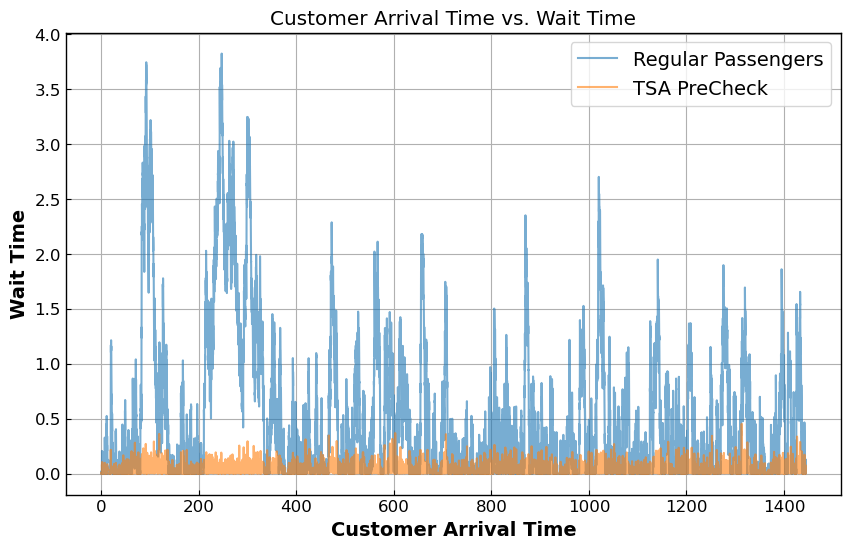

In [30]:
# Extract data for plotting
y1_wait_times_regular = [wait_times_regular[cid] for cid in wait_times_regular.keys()]
y2_wait_times_precheck = [
    wait_times_precheck[cid] for cid in wait_times_precheck.keys()
]
x1 = [arrival_times_regular[cid] for cid in wait_times_regular.keys()]
x2 = [arrival_times_precheck[cid] for cid in wait_times_precheck.keys()]

plt.figure(figsize=(10, 6))
plt.plot(x1, y1_wait_times_regular, label="Regular Passengers", alpha=0.6)
plt.plot(x2, y2_wait_times_precheck, label="TSA PreCheck", alpha=0.6)
plt.xlabel("Customer Arrival Time")
plt.ylabel("Wait Time")
plt.title("Customer Arrival Time vs. Wait Time")
plt.legend()
plt.grid(True)
plt.savefig("./plots/trace_plot.png")
plt.show()

- There are no signs of queue divergence, which is a good sign.
- There are periods where the wait times are high, but they are not persistent.
- The wait times for TSA PreCheck passengers are generally much lower than for regular passengers, which is expected.

#### Distribution of Wait Times

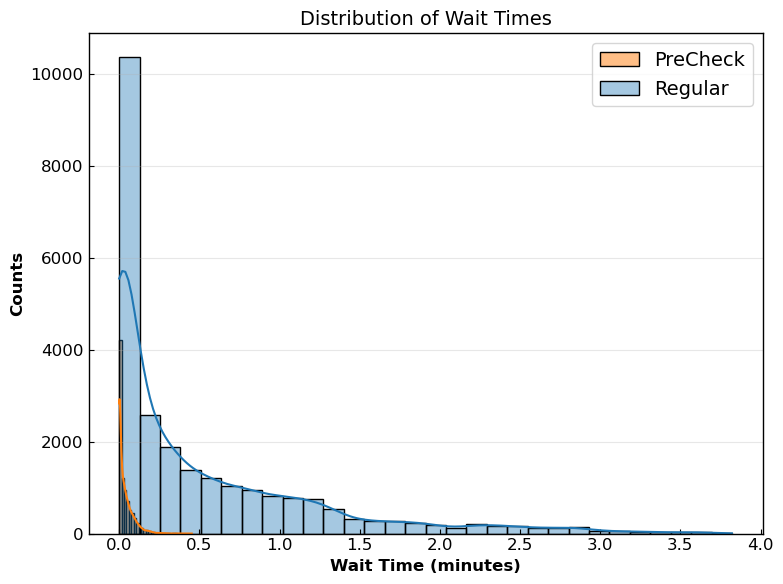

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(
    list(wait_times_precheck.values()),
    bins=30,
    kde=True,
    color=sns.color_palette()[1],
    label="PreCheck",
)
sns.histplot(
    list(wait_times_regular.values()),
    bins=30,
    kde=True,
    color=sns.color_palette()[0],
    label="Regular",
    alpha=0.4,
)
plt.xlabel("Wait Time (minutes)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.title("Distribution of Wait Times", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/wait_time_distribution.png")
plt.show()

- The tail of the wait time distribution is long for regular passengers, which is expected due to properties of the exponential distribution.
- Exponential distributions mean wait times tend to be short but some passengers will have very long wait times.

### Multiple Simulations

- Now we run multiple simulations to get a distribution of wait times.
- We average the metrics and report the final results.

In [32]:
num_sims = 500
wait_times_precheck_list = []
wait_times_regular_list = []
arrival_times_precheck_list = []
arrival_times_regular_list = []
throughput_precheck_list = []
throughput_regular_list = []

In [33]:
for _ in range(num_sims):
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        NUM_SERVERS,
    )

    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    wait_times_precheck_list.extend(list(wait_times_precheck.values()))
    wait_times_regular_list.extend(list(wait_times_regular.values()))
    arrival_times_precheck_list.extend(list(arrival_times_precheck.values()))
    arrival_times_regular_list.extend(list(arrival_times_regular.values()))

    # Get the final simulation time (last event time)
    total_time = max(
        max(arrival_times_precheck.values(), default=0),
        max(arrival_times_regular.values(), default=0),
    )

    # Calculate throughputs
    throughput_precheck_list.append(
        calculate_throughput(wait_times_precheck, total_time)
    )
    throughput_regular_list.append(calculate_throughput(wait_times_regular, total_time))

In [34]:
print_results(np.array(wait_times_precheck_list), np.array(wait_times_regular_list))

TSA PreCheck:
  Average wait time: 0.04
  Variance of wait times: 0.00
  Max wait time: 0.75

Regular Passengers:
  Average wait time: 0.53
  Variance of wait times: 0.49
  Max wait time: 9.79


In [35]:
print(
    f"Average PreCheck Throughput: {np.mean(throughput_precheck_list):.2f} passengers/minute"
)
print(
    f"Average Regular Throughput: {np.mean(throughput_regular_list):.2f} passengers/minute"
)

Average PreCheck Throughput: 6.37 passengers/minute
Average Regular Throughput: 17.22 passengers/minute


- Throughput is higher for regular passengers because they have a higher arrival rate and the system is stable.

In [36]:
avg_precheck = np.mean(wait_times_precheck_list)
avg_regular = np.mean(wait_times_regular_list)

weighted_avg = avg_precheck * PRECHECK_PROB + avg_regular * (1 - PRECHECK_PROB)
print(f"Weighted Average Wait Time: {weighted_avg:.2f} minutes")

Weighted Average Wait Time: 0.40 minutes


**Metrics Table**

||  Average Wait Time (min) | Max Wait Time (min) | Average Throughput (passengers/min) | $\rho$ |
|-----| ---- | ---- | ---- | ---- |
| PreCheck | 0.04 | 0.75 | 6.37 | 0.75 |
| Regular | 0.53 | 9.79 | 17.22 | 0.998 |

### Airport Cost Optimization

$$
T(c, \mu) = c_ss + (c_{\mu} \mu^3) c + c_wL(\lambda, c, \mu)
$$
- $c_s$: cost of a server per hour
    - Can be interpreted as base pay
- $c_w$: cost of a customer waiting per hour
- $\mu$: service rate of the servers
- $c_{\mu}$: cost of a service rate per server per hour
    - Can be interpreted as bonus pay
- $L$: average number of customers in the system
- $c$: number of servers

The decision variables are $c$ and $\mu$.

In [60]:
# Set the parameters
# To get cost per minute we divide by 60
cs = 30 / 60
cw = 37 / 60
cmu = cs * 0.06

# Arrival rate (per minute)
lam = ARRIVAL_RATE
# average service rate (passengers/minute)
mu = np.mean([SERVICE_RATE_REGULAR, SERVICE_RATE_PRECHECK])
# Number of servers
s = 12  # servers

- TSA agent average wage is $28 hour. We'll round to $30/hour.

In [ ]:
# Define the functions
def erlang_c(s, mu, lam):
    rho = lam / (s * mu)
    # unstable system, infinite queue
    if rho >= 1:
        return np.inf

    s_int = int(np.floor(s))
    # Sum of terms for states 0 to s-1
    sum_terms = sum((s * rho) ** n / factorial(n) for n in range(s_int))
    numerator = ((s * rho) ** s_int / factorial(s_int)) * (1 / (1 - rho))
    denom = sum_terms + numerator
    P_wait = numerator / denom

    Lq = P_wait * (rho / (1 - rho))
    L = Lq + lam / mu
    return L


def total_cost(x):
    s, mu = x
    if s < 1 or mu <= 0:
        return 1e10  # Penalize invalid parameters

    L = erlang_c(s, mu, lam)
    if L == np.inf:
        return 1e10  # Penalize unstable systems

    # return cs * s + cw * Ls + cmu * np.exp(0.8 * mu) * s
    return cs * s + cw * L + cmu * mu**2 * s

In [63]:
# Initial guess
x0 = [11, 1]
server_bounds = (3, 15)
service_rate_bounds = (0.5, SERVICE_RATE_PRECHECK * 1.33)

bounds = [
    server_bounds,
    service_rate_bounds,
]

result = basinhopping(
    total_cost,
    x0,
    niter=1000,
    T=1.0,
    stepsize=0.5,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "bounds": bounds,
        "options": {
            "gtol": 1e-8,
            "maxiter": 2000,
            "finite_diff_rel_step": 1e-8,
        },
    },
)

opt_s, opt_mu = result.x
print(f"Optimal number of servers: {opt_s:.2f}")
print(f"Optimal service rate per server: {opt_mu:.2f}")
print(f"Minimum total cost: {result.fun:.2f}")

Optimal number of servers: 9.00
Optimal service rate per server: 3.48
Minimum total cost: 12.58


In [55]:
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

# # Create grid of s and mu values
# s_values = np.linspace(server_bounds[0], server_bounds[1] * 1.2, 100)
# mu_values = np.linspace(service_rate_bounds[0], service_rate_bounds[1] * 1.2, 100)
# S, MU = np.meshgrid(s_values, mu_values)

# # Compute total cost for each combination
# Cost = np.zeros_like(S)

# for i in range(len(s_values)):
#     for j in range(len(mu_values)):
#         Cost[j, i] = total_cost([S[j, i], MU[j, i]])

# Cost_clipped = np.clip(Cost, None, 150)  # replace 100 with the max Z you want to show


# # Create 3D figure
# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection="3d")

# # Surface plot
# surf = ax.plot_surface(S, MU, Cost_clipped, cmap="viridis", edgecolor="none", alpha=0.9)

# # Optional: contour lines on the bottom
# ax.contour(
#     S,
#     MU,
#     Cost_clipped,
#     zdir="z",
#     offset=np.min(Cost),
#     cmap="viridis",
#     linestyles="solid",
# )

# # Color bar
# fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Total Cost")

# # # Mark optimal point
# # optimal_s = result.x[0]
# # optimal_mu = result.x[1]
# # optimal_cost = total_cost([optimal_s, optimal_mu])
# # ax.scatter(optimal_s, optimal_mu, optimal_cost, color='red', s=100, edgecolor='black', label='Optimal')

# # Labels
# ax.set_xlabel("Number of Servers (c)")
# ax.set_ylabel("Service Rate ($\\mu$)")
# ax.set_zlabel("Total Cost")
# ax.set_title("Total Cost Surface Plot ($\\mu$ vs c)")
# # ax.legend()

# plt.show()

In [56]:
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from matplotlib.animation import FuncAnimation

# # -- Your grid and Cost_clipped code here --
# # s_values, mu_values, S, MU, Cost, Cost_clipped

# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection="3d")

# # Surface plot
# surf = ax.plot_surface(S, MU, Cost_clipped, cmap="viridis", edgecolor="none", alpha=0.9)

# # Labels
# ax.set_xlabel("Number of Servers (c)")
# ax.set_ylabel("Service Rate ($\\mu$)")
# ax.set_zlabel("Total Cost")
# ax.set_title("Total Cost Surface Plot ($\\mu$ vs c)")


# # Animation function
# def rotate(angle):

#     ax.view_init(elev=30, azim=angle)


# # Create animation
# ani = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=50)

# # To display inline in Jupyter
# from IPython.display import HTML

# # HTML(ani.to_jshtml())

# # Or to save as GIF
# ani.save("spinning_surface.gif", writer="pillow")

- We choose $x^3$ because the function starts off slower than $x^2$ then grows rapidly overtaking $x^2$.
- The function mimics the cost of increasing the service rate. You can incentivize small gains, but it takes much more to push a person because humans have capacity limits.


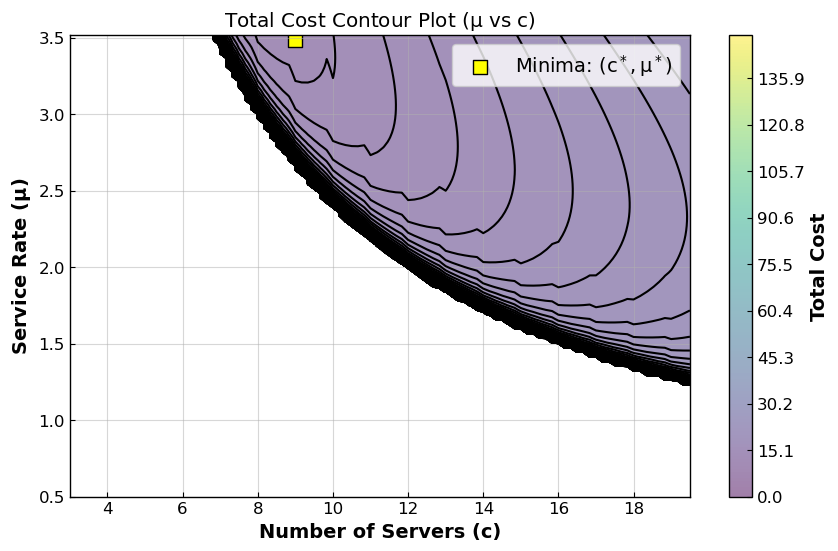

In [75]:
# Create a grid of s and mu values
s_values = np.linspace(server_bounds[0], server_bounds[1] * 1.3, 100)
mu_values = np.linspace(service_rate_bounds[0], service_rate_bounds[1] * 1.01, 100)

# Compute total cost for each combination
S, MU = np.meshgrid(s_values, mu_values)
Cost = np.zeros_like(S)

for i in range(len(s_values)):
    for j in range(len(mu_values)):
        Cost[j, i] = total_cost([S[j, i], MU[j, i]])

# Plot contour lines
plt.figure(figsize=(10, 6))
contour_levels = np.linspace(0, 150, 150)  # Adjust levels as needed
contour_plot = plt.contour(S, MU, Cost, levels=contour_levels, colors="k")

# Add color gradient (optional)
plt.contourf(S, MU, Cost, levels=contour_levels, cmap="viridis", alpha=0.5)
plt.colorbar(label="Total Cost")

# Mark the optimal point (if known)
optimal_s = result.x[0]
optimal_mu = result.x[1]
plt.scatter(
    optimal_s,
    optimal_mu,
    color="yellow",
    marker="s",
    label="Minima: ($c^*, \\mu^*$)",
    s=100,
    edgecolor="black",
)

# Labels and title
plt.xlabel("Number of Servers (c)")
plt.ylabel("Service Rate ($\\mu$)")
plt.title("Total Cost Contour Plot ($\\mu$ vs c)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.savefig("./plots/loss_surface.png")
plt.show()

## Change in Optima, for changes in cmu

In [80]:
# Set the parameters
# To get cost per minute we divide by 60
cs = 30 / 60
cw = 37 / 60


# Arrival rate (per minute)
lam = ARRIVAL_RATE
# average service rate (passengers/minute)
mu = np.mean([SERVICE_RATE_REGULAR, SERVICE_RATE_PRECHECK])
# Number of servers
s = 12  # servers

In [81]:
cmu = cs * 0.06

cmu_candidates = np.linspace(cmu * 0.8, cmu * 8, 8)
cmu_candidates

array([0.024     , 0.05485714, 0.08571429, 0.11657143, 0.14742857,
       0.17828571, 0.20914286, 0.24      ])

In [118]:
optimas = []
verbose = True

for cmu in cmu_candidates:
    # Define the functions
    def erlang_c(s, mu, lam):
        rho = lam / (s * mu)
        # unstable system, infinite queue
        if rho >= 1:
            return np.inf

        s_int = int(np.floor(s))
        # Sum of terms for states 0 to s-1
        sum_terms = sum((s * rho) ** n / factorial(n) for n in range(s_int))
        numerator = ((s * rho) ** s_int / factorial(s_int)) * (1 / (1 - rho))
        denom = sum_terms + numerator
        P_wait = numerator / denom

        Lq = P_wait * (rho / (1 - rho))
        L = Lq + lam / mu
        return L

    def total_cost(x):
        s, mu = x
        if s < 1 or mu <= 0:
            return 1e10  # Penalize invalid parameters

        L = erlang_c(s, mu, lam)
        if L == np.inf:
            return 1e10  # Penalize unstable systems

        # return cs * s + cw * Ls + cmu * np.exp(0.8 * mu) * s
        return cs * s + cw * L + cmu * mu**2 * s

    # Initial guess
    x0 = [11, 1]
    server_bounds = (3, 15)
    service_rate_bounds = (0.5, SERVICE_RATE_PRECHECK * 1.33)

    bounds = [
        server_bounds,
        service_rate_bounds,
    ]

    result = basinhopping(
        total_cost,
        x0,
        niter=1000,
        T=1.0,
        stepsize=0.5,
        minimizer_kwargs={
            "method": "L-BFGS-B",
            "bounds": bounds,
            "options": {
                "gtol": 1e-8,
                "maxiter": 2000,
                "finite_diff_rel_step": 1e-8,
            },
        },
    )
    if verbose:
        print(f"Optimal number of servers: {result.x[0]:.2f}")
        print(f"Optimal service rate per server: {result.x[1]:.2f}")
        print(f"Minimum total cost: {result.fun:.2f}")

    optimas.append((cmu, result.x[0], result.x[1], cmu))

Optimal number of servers: 9.00
Optimal service rate per server: 3.48
Minimum total cost: 11.93
Optimal number of servers: 9.00
Optimal service rate per server: 3.39
Minimum total cost: 15.26
Optimal number of servers: 9.00
Optimal service rate per server: 3.23
Minimum total cost: 18.27
Optimal number of servers: 10.00
Optimal service rate per server: 2.85
Minimum total cost: 20.98
Optimal number of servers: 11.00
Optimal service rate per server: 2.57
Minimum total cost: 23.34
Optimal number of servers: 12.00
Optimal service rate per server: 2.34
Minimum total cost: 25.45
Optimal number of servers: 13.00
Optimal service rate per server: 2.14
Minimum total cost: 27.38
Optimal number of servers: 14.00
Optimal service rate per server: 1.98
Minimum total cost: 29.17


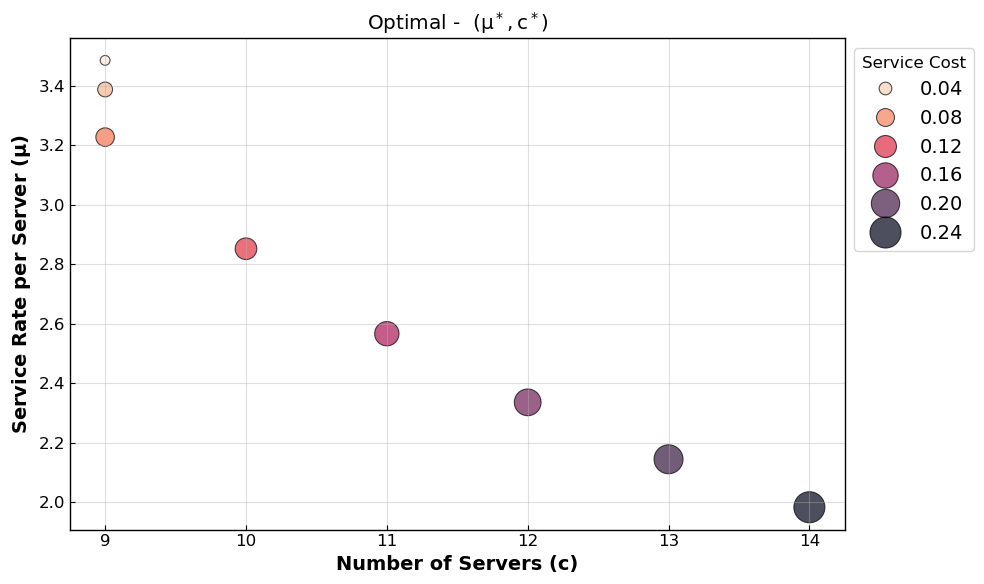

In [119]:
import seaborn as sns

# Prepare data for seaborn
df = pd.DataFrame(
    {
        "Servers": [opt[1] for opt in optimas],
        "ServiceRate": [opt[2] for opt in optimas],
        "Service Cost": [opt[3] for opt in optimas],
    }
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Servers",
    y="ServiceRate",
    size="Service Cost",
    hue="Service Cost",
    sizes=(50, 500),  # min/max bubble size
    palette="rocket_r",
    edgecolor="k",
    alpha=0.7,
    ax=ax,
)

ax.set_title("Optimal -  $(\\mu^*, c^*)$")
ax.set_xlabel("Number of Servers (c)")
ax.set_ylabel("Service Rate per Server $(\\mu)$")
ax.grid(alpha=0.4)

# Move legend and make it cleaner
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Version 2 (Failed)

- Feel free to ignore this section; it is not used in the final model.
- This baseline model is an M/M/c queue, where c is the number of servers.
- The lines are parallel. There is a dedicated server for each line, regular and precheck. This is more akin to CLEAR than PreCheck.
- This model has a closed-form solution.

In [41]:
# Parameters (units: passengers per minute)
ARRIVAL_RATE_REGULAR = 23.6
PRECHECK_PROB = 0.27
ARRIVAL_RATE_PRECHECK = ARRIVAL_RATE_REGULAR * PRECHECK_PROB

SERVICE_RATE_REGULAR = 1.9701
SERVICE_RATE_PRECHECK = SERVICE_RATE_REGULAR * 1.33

NUM_SERVERS = 12
MAX_CUST = 34000

# Initialize server pools (25% PreCheck, 75% regular)
servers_precheck = [0.0] * int(NUM_SERVERS * 0.2)
servers_regular = [0.0] * int(NUM_SERVERS * 0.8)

In [42]:
rho = ARRIVAL_RATE_REGULAR / (len(servers_regular) * SERVICE_RATE_REGULAR)
rho

1.3310097062190867

In [43]:
rho = ARRIVAL_RATE_PRECHECK / (len(servers_precheck) * SERVICE_RATE_PRECHECK)
rho

1.2159224007941278

- Right off the bat, the stability condition is not satisfied with the parallel system. This means that the priority queue version is superior to the parallel system approach.
- This harkens back to the class poll on whether we should divide up resources or not—the answer in class was no.


### Sensitivity Analysis

In [44]:
# Units are passengers per minute
ARRIVAL_RATE = 23.6
# These are lower bounds
# Service rate for regular passengers, units are passengers per minute
SERVICE_RATE_REGULAR = round(mu_est, 4)
# Faster service rate for TSA PreCheck
SERVICE_RATE_PRECHECK = SERVICE_RATE_REGULAR * 1.33
PRECHECK_PROB = 0.27  # Probability of being PreCheck
NUM_SERVERS = 12
MAX_CUST = round(lambda_constant * 24, -3)

#### Services Rates

In [45]:
service_rate_regular_candidates = np.linspace(
    SERVICE_RATE_REGULAR * 0.5, SERVICE_RATE_REGULAR * 1.5, 100
)
service_rate_precheck_candidates = service_rate_regular_candidates * 1.33

In [46]:
stats_dict = {}

for service_rate_regular, service_rate_precheck in zip(
    service_rate_regular_candidates, service_rate_precheck_candidates
):
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        service_rate_precheck,
        service_rate_regular,
        NUM_SERVERS,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))
    max_precheck = max(wait_times_precheck.values())
    max_regular = max(wait_times_regular.values())

    stats_dict[service_rate_regular] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "max_precheck": max_precheck,
        "max_regular": max_regular,
    }

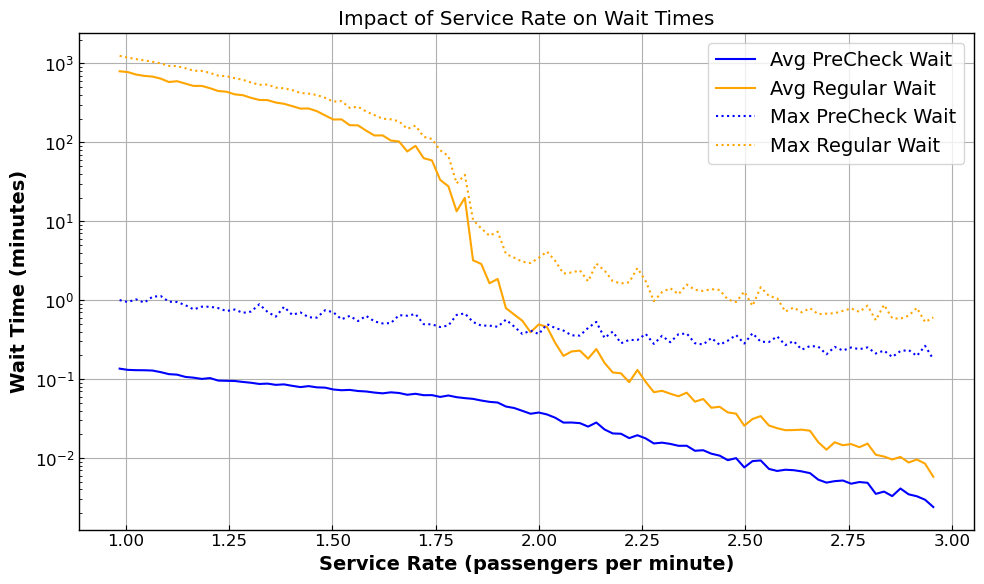

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

service_rate_regular = list(stats_dict.keys())
avg_precheck_values = [stat["avg_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["avg_regular"] for stat in stats_dict.values()]
max_precheck_values = [stat["max_precheck"] for stat in stats_dict.values()]
max_regular_values = [stat["max_regular"] for stat in stats_dict.values()]

ax.plot(
    service_rate_regular,
    avg_precheck_values,
    label="Avg PreCheck Wait",
    color="blue",
)
ax.plot(
    service_rate_regular,
    avg_regular_values,
    label="Avg Regular Wait",
    color="orange",
)
ax.plot(
    service_rate_regular,
    max_precheck_values,
    label="Max PreCheck Wait",
    linestyle=":",
    color="blue",
)
ax.plot(
    service_rate_regular,
    max_regular_values,
    label="Max Regular Wait",
    linestyle=":",
    color="orange",
)
ax.set_xlabel("Service Rate (passengers per minute)")
ax.set_ylabel("Wait Time (minutes)")
ax.set_title("Impact of Service Rate on Wait Times")
ax.legend()
ax.set_yscale("log")
ax.grid(True)
plt.tight_layout()
plt.savefig("./plots/service_rate_sens.png")
plt.show()

#### PreCheck Probability

In [48]:
# range from 1% of customers to 50% of customers
precheck_prob_candidates = np.linspace(0.01, 0.6, 100)

stats_dict = {}

for precheck_prob in precheck_prob_candidates:
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        precheck_prob,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        NUM_SERVERS,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))

    # Get the final simulation time (last event time)
    total_time = max(
        max(arrival_times_precheck.values(), default=0),
        max(arrival_times_regular.values(), default=0),
    )

    # Calculate throughputs
    throughput_precheck = calculate_throughput(wait_times_precheck, total_time)

    throughput_regular = calculate_throughput(wait_times_regular, total_time)

    stats_dict[precheck_prob] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "throughput_precheck": throughput_precheck,
        "throughput_regular": throughput_regular,
    }

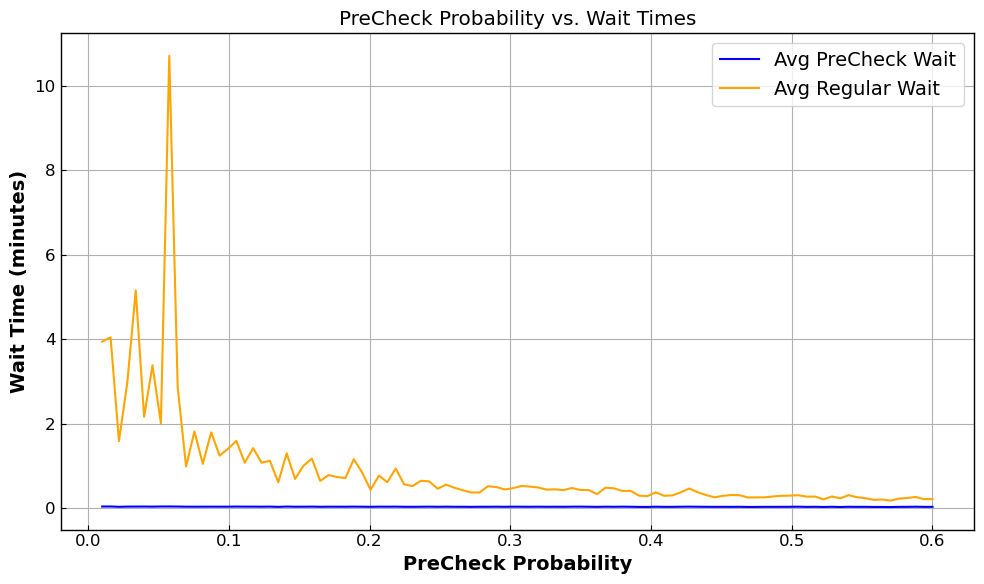

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

precheck_prob_candidates = list(stats_dict.keys())
avg_precheck_values = [stat["avg_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["avg_regular"] for stat in stats_dict.values()]

ax.plot(
    precheck_prob_candidates,
    avg_precheck_values,
    label="Avg PreCheck Wait",
    color="blue",
)
ax.plot(
    precheck_prob_candidates,
    avg_regular_values,
    label="Avg Regular Wait",
    color="orange",
)
ax.set_xlabel("PreCheck Probability")
ax.set_ylabel("Wait Time (minutes)")
ax.set_title("PreCheck Probability vs. Wait Times")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("./plots/precheck_wait_time_sens.png")
plt.show()

- In a pooled queue, it makes sense that precheck probability doesn't crowd out regular passengers. It is beneficial because it reduces the number of regular passengers in the system.
- PreCheck is also faster.


# M/N/c Models

## Functions

**TSA PreCheck Function**

- Models a single TSA PreCheck Security Screening
- Uses a normal distribution for the service times.


In [50]:
def TSA_Precheck_Line(a, service_mean, service_std, ncust):
    """
    Simulates an M/N/1 queue for TSA Precheck.

    Inputs:
       a: average number of arrivals per minute.
       service_mean: mean service time per customer.
       service_std: standard deviation of service time.
       ncust: number of customers to simulate.
    Outputs:
       at = arrival time of a person joining the queue.
       st = service time once they reach the front.
       ft = finish time after waiting and being served.
       wt = waiting time before being served.
    """
    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times assuming an normal distribution
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    server_one_available_times = [0]

    # Compute finish times
    ft = np.zeros(ncust)
    ft[0] = at[0] + st[0]  # First customer's finish time

    # compute finish time for each customer as the larger of
    # arrival time plus service time (if no wait)
    # finish time of previous customer plus service time (if wait)
    for i in range(1, ncust):
        if at[i] < ft[i - 1]:
            wt[i] = ft[i - 1] - at[i]
            ft[i] = ft[i - 1] + st[i]
        else:
            wt[i] = 0
            ft[i] = at[i] + st[i]

    return at, ft, st, wt

**Standard Screening Function**
- Models a screening checkpoint with 3 servers.
- This will be used for the M/M/4 case where we have three lines for regular and one line for TSA PreCheck.
- Since parallel lines can be treated as independent queues, we can use the M/M/c model for each line.

In [51]:
def Regular_Security_Line(a, service_mean, service_std, ncust):
    """
    Simulates an M/M/3 queue with normal service times.

    Inputs:
       a: average number of arrivals per minute
       service_mean: mean service time per customer
       service_std: standard deviation of service time
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       st = service time once they reach the front
       ft = finish time after waiting and being served
       wt = waiting time in queue before service begins
    """
    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times using normal distribution
    # Ensure service times are positive by using absolute value or truncation
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    # Initialize arrays for results
    ft = np.zeros(ncust)  # Finish times
    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    # Track when each server becomes available
    server_one_available_times = [0]
    server_two_available_times = [0]
    server_three_available_times = [0]

    for i in range(ncust):
        # Find the earliest available server
        if (
            server_one_available_times[-1] <= server_two_available_times[-1]
            and server_one_available_times[-1] <= server_three_available_times[-1]
        ):
            earliest_available_time = server_one_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_one_available_times.append(ft[i])

        elif server_two_available_times[-1] <= server_three_available_times[-1]:
            earliest_available_time = server_two_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_two_available_times.append(ft[i])

        else:
            earliest_available_time = server_three_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]
            server_three_available_times.append(ft[i])

    return at, ft, st, wt

**Two Lane Security Screening Function**

- Models a security checkpoint with two lanes.
- This will be used for both standard screening and PreCheck screening.
- This will be used for the M/M/4 case where we have two lines for regular and two lines for TSA PreCheck.

In [52]:
def Two_Lane_Security(a, service_mean, service_std, ncust):
    """
    Simulates an M/N/2 queue with normal service times.

    Inputs:
       a: average number of arrivals per minute
       service_mean: mean service time per customer
       service_std: standard deviation of service time
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       st = service time once they reach the front
       ft = finish time after waiting and being served
       wt = waiting time in queue before service begins
    """

    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times using normal distribution
    # Ensure service times are positive by using absolute value or truncation
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    # Initialize arrays for results
    ft = np.zeros(ncust)  # Finish times
    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    # Track when each server becomes available
    server_one_available_times = [0]
    server_two_available_times = [0]

    for i in range(ncust):
        # Find the earliest available server
        if server_one_available_times[-1] <= server_two_available_times[-1]:
            earliest_available_time = server_one_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_one_available_times.append(ft[i])

        else:
            earliest_available_time = server_two_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_two_available_times.append(ft[i])

    return at, ft, st, wt

**Precheck Customer Percentage by Price function**


Returns the customer percentage for TSA PreCheck by price.  This assumes a linear demand from full participation at 100 to 30 percent participation at $76.75.  Participation data from https://www.washingtonpost.com/travel/2024/11/28/tsa-precheck-vs-standard-security-line/
This is calculated as a function of price p.

The assumption of change in dollar per percentage change is set to 1.096429, calculated by Current Price/Percentage not participating = $76.75/70 = 1.096429

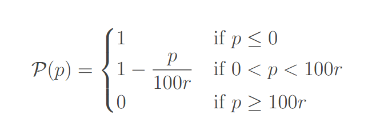

In [53]:
def Precheck_Customers__Percentage_By_Price(price):
    """
    Returns the number of customers that use TSA Precheck as a result of price

    Inputs:
       Price: price of TSA Precheck
    Outputs:
       participation rate: percentage of customers that use TSA Precheck as a result of price
    """

    assumption_dollar_per_percentage = (
        1.096429  # Calculated from the 30% of travelers at $76.75 dollar cost
    )

    return max(0, min(1, (100 - price / assumption_dollar_per_percentage) / 100))

**Run Cost Analysis**

This function runs a series of simulations for a given price range and returns the results, including total wait time, average wait time, max wait time, throughputs, and counts for both screening types.  This then averages across the simulations for the price ranges.

This function will be used to evaluate the 3:1 configuration.



In [54]:
def run_cost_analysis(
    price_range, customer_count, service_params, arrival_rate, num_simulations=10
):
    """
    Analyze total wait times across different TSA Precheck prices

    Inputs:
        price_range: list or array of TSA prices to test
        customer_count: total number of customers to simulate
        service_params: dict with service time parameters
        arrival_rate: total arrival rate per minute
        num_simulations: number of simulation runs per price point for averaging

    Outputs:
        results_df: DataFrame with analysis results
    """

    results = []

    for price in price_range:
        print(f"Testing price: ${price}")

        # Run multiple simulations for this price point
        price_results = []

        for sim in range(num_simulations):
            # Calculate demand split
            precheck_percentage = Precheck_Customers__Percentage_By_Price(price)

            # Handle edge cases
            if precheck_percentage <= 0:
                # No one uses precheck - everyone goes to regular line
                standard_customers = customer_count
                precheck_customers = 0
                standard_arrival_rate = arrival_rate
                precheck_arrival_rate = 0
            elif precheck_percentage >= 1:
                # Everyone uses precheck - no one goes to regular line
                standard_customers = 0
                precheck_customers = customer_count
                standard_arrival_rate = 0
                precheck_arrival_rate = arrival_rate
            else:
                # Normal split
                precheck_arrival_rate = arrival_rate * precheck_percentage
                standard_arrival_rate = arrival_rate * (1 - precheck_percentage)
                standard_customers = int((1 - precheck_percentage) * customer_count)
                precheck_customers = int(precheck_percentage * customer_count)

            # Run simulations
            total_wait_time = 0
            total_customers_served = 0

            if standard_customers > 0:
                standard_at, standard_ft, standard_st, standard_wt = (
                    Regular_Security_Line(
                        standard_arrival_rate,
                        service_params["regular_mean"],
                        service_params["regular_std"],
                        standard_customers,
                    )
                )
                total_wait_time += np.sum(standard_wt)
                total_customers_served += standard_customers

            if precheck_customers > 0:
                precheck_at, precheck_ft, precheck_st, precheck_wt = TSA_Precheck_Line(
                    precheck_arrival_rate,
                    service_params["precheck_mean"],
                    service_params["precheck_std"],
                    precheck_customers,
                )
                total_wait_time += np.sum(precheck_wt)
                total_customers_served += precheck_customers

            # Calculate metrics for this simulation
            avg_wait_time = (
                total_wait_time / total_customers_served
                if total_customers_served > 0
                else 0
            )

            # Calculate line-specific metrics
            if standard_customers > 0:
                avg_wait_standard = np.mean(standard_wt)
                max_wait_standard = np.max(standard_wt)
                throughput_standard = (
                    standard_customers / standard_ft[-1] if len(standard_ft) > 0 else 0
                )
            else:
                avg_wait_standard = 0
                max_wait_standard = 0
                throughput_standard = 0

            if precheck_customers > 0:
                avg_wait_precheck = np.mean(precheck_wt)
                max_wait_precheck = np.max(precheck_wt)
                throughput_precheck = (
                    precheck_customers / precheck_ft[-1] if len(precheck_ft) > 0 else 0
                )
            else:
                avg_wait_precheck = 0
                max_wait_precheck = 0
                throughput_precheck = 0

            price_results.append(
                {
                    "price": price,
                    "precheck_percentage": precheck_percentage,
                    "total_wait_time": total_wait_time,
                    "avg_wait_time": avg_wait_time,
                    "standard_customers": standard_customers,
                    "precheck_customers": precheck_customers,
                    "avg_wait_standard": avg_wait_standard,
                    "avg_wait_precheck": avg_wait_precheck,
                    "max_wait_standard": max_wait_standard,
                    "max_wait_precheck": max_wait_precheck,
                    "throughput_standard": throughput_standard,
                    "throughput_precheck": throughput_precheck,
                }
            )

        # Average results across simulations for this price
        avg_results = {
            "price": price,
            "precheck_percentage": np.mean(
                [r["precheck_percentage"] for r in price_results]
            ),
            "total_wait_time_mean": np.mean(
                [r["total_wait_time"] for r in price_results]
            ),
            "total_wait_time_std": np.std(
                [r["total_wait_time"] for r in price_results]
            ),
            "avg_wait_time_mean": np.mean([r["avg_wait_time"] for r in price_results]),
            "avg_wait_time_std": np.std([r["avg_wait_time"] for r in price_results]),
            "standard_customers_mean": np.mean(
                [r["standard_customers"] for r in price_results]
            ),
            "precheck_customers_mean": np.mean(
                [r["precheck_customers"] for r in price_results]
            ),
            "avg_wait_standard_mean": np.mean(
                [r["avg_wait_standard"] for r in price_results]
            ),
            "avg_wait_standard_std": np.std(
                [r["avg_wait_standard"] for r in price_results]
            ),
            "avg_wait_precheck_mean": np.mean(
                [r["avg_wait_precheck"] for r in price_results]
            ),
            "avg_wait_precheck_std": np.std(
                [r["avg_wait_precheck"] for r in price_results]
            ),
            "max_wait_standard_mean": np.mean(
                [r["max_wait_standard"] for r in price_results]
            ),
            "max_wait_standard_std": np.std(
                [r["max_wait_standard"] for r in price_results]
            ),
            "max_wait_precheck_mean": np.mean(
                [r["max_wait_precheck"] for r in price_results]
            ),
            "max_wait_precheck_std": np.std(
                [r["max_wait_precheck"] for r in price_results]
            ),
            "throughput_standard_mean": np.mean(
                [r["throughput_standard"] for r in price_results]
            ),
            "throughput_standard_std": np.std(
                [r["throughput_standard"] for r in price_results]
            ),
            "throughput_precheck_mean": np.mean(
                [r["throughput_precheck"] for r in price_results]
            ),
            "throughput_precheck_std": np.std(
                [r["throughput_precheck"] for r in price_results]
            ),
        }

        results.append(avg_results)

    return pd.DataFrame(results)

**Run Cost Analysis Split Lanes**

This function runs a series of simulations for a given price range and returns the results, including total wait time, average wait time, max wait time, throughputs, and counts for both screening types.  This then averages across the simulations for the price ranges.

This function will be used to evaluate the 2:2 configuration.



In [55]:
def run_cost_analysis_split_lanes(
    price_range, customer_count, service_params, arrival_rate, num_simulations=10
):
    """
    Analyze total wait times across different TSA Precheck prices

    Inputs:
        price_range: list or array of TSA prices to test
        customer_count: total number of customers to simulate
        service_params: dict with service time parameters
        arrival_rate: total arrival rate per minute
        num_simulations: number of simulation runs per price point for averaging

    Outputs:
        results_df: DataFrame with analysis results
    """

    results = []

    for price in price_range:
        print(f"Testing price: ${price}")

        # Run multiple simulations for this price point
        price_results = []

        for sim in range(num_simulations):
            # Calculate demand split
            precheck_percentage = Precheck_Customers__Percentage_By_Price(price)

            # Handle edge cases
            if precheck_percentage <= 0:
                # No one uses precheck - everyone goes to regular line
                standard_customers = customer_count
                precheck_customers = 0
                standard_arrival_rate = arrival_rate
                precheck_arrival_rate = 0
            elif precheck_percentage >= 1:
                # Everyone uses precheck - no one goes to regular line
                standard_customers = 0
                precheck_customers = customer_count
                standard_arrival_rate = 0
                precheck_arrival_rate = arrival_rate
            else:
                # Normal split
                precheck_arrival_rate = arrival_rate * precheck_percentage
                standard_arrival_rate = arrival_rate * (1 - precheck_percentage)
                standard_customers = int((1 - precheck_percentage) * customer_count)
                precheck_customers = int(precheck_percentage * customer_count)

            # Run simulations
            total_wait_time = 0
            total_customers_served = 0

            if standard_customers > 0:
                standard_at, standard_ft, standard_st, standard_wt = Two_Lane_Security(
                    standard_arrival_rate,
                    service_params["regular_mean"],
                    service_params["regular_std"],
                    standard_customers,
                )
                total_wait_time += np.sum(standard_wt)
                total_customers_served += standard_customers

            if precheck_customers > 0:
                precheck_at, precheck_ft, precheck_st, precheck_wt = Two_Lane_Security(
                    precheck_arrival_rate,
                    service_params["precheck_mean"],
                    service_params["precheck_std"],
                    precheck_customers,
                )
                total_wait_time += np.sum(precheck_wt)
                total_customers_served += precheck_customers

            # Calculate metrics for this simulation
            avg_wait_time = (
                total_wait_time / total_customers_served
                if total_customers_served > 0
                else 0
            )

            # Calculate line-specific metrics
            if standard_customers > 0:
                avg_wait_standard = np.mean(standard_wt)
                max_wait_standard = np.max(standard_wt)
                throughput_standard = (
                    standard_customers / standard_ft[-1] if len(standard_ft) > 0 else 0
                )
            else:
                avg_wait_standard = 0
                max_wait_standard = 0
                throughput_standard = 0

            if precheck_customers > 0:
                avg_wait_precheck = np.mean(precheck_wt)
                max_wait_precheck = np.max(precheck_wt)
                throughput_precheck = (
                    precheck_customers / precheck_ft[-1] if len(precheck_ft) > 0 else 0
                )
            else:
                avg_wait_precheck = 0
                max_wait_precheck = 0
                throughput_precheck = 0

            price_results.append(
                {
                    "price": price,
                    "precheck_percentage": precheck_percentage,
                    "total_wait_time": total_wait_time,
                    "avg_wait_time": avg_wait_time,
                    "standard_customers": standard_customers,
                    "precheck_customers": precheck_customers,
                    "avg_wait_standard": avg_wait_standard,
                    "avg_wait_precheck": avg_wait_precheck,
                    "max_wait_standard": max_wait_standard,
                    "max_wait_precheck": max_wait_precheck,
                    "throughput_standard": throughput_standard,
                    "throughput_precheck": throughput_precheck,
                }
            )

        # Average results across simulations for this price
        avg_results = {
            "price": price,
            "precheck_percentage": np.mean(
                [r["precheck_percentage"] for r in price_results]
            ),
            "total_wait_time_mean": np.mean(
                [r["total_wait_time"] for r in price_results]
            ),
            "total_wait_time_std": np.std(
                [r["total_wait_time"] for r in price_results]
            ),
            "avg_wait_time_mean": np.mean([r["avg_wait_time"] for r in price_results]),
            "avg_wait_time_std": np.std([r["avg_wait_time"] for r in price_results]),
            "standard_customers_mean": np.mean(
                [r["standard_customers"] for r in price_results]
            ),
            "precheck_customers_mean": np.mean(
                [r["precheck_customers"] for r in price_results]
            ),
            "avg_wait_standard_mean": np.mean(
                [r["avg_wait_standard"] for r in price_results]
            ),
            "avg_wait_standard_std": np.std(
                [r["avg_wait_standard"] for r in price_results]
            ),
            "avg_wait_precheck_mean": np.mean(
                [r["avg_wait_precheck"] for r in price_results]
            ),
            "avg_wait_precheck_std": np.std(
                [r["avg_wait_precheck"] for r in price_results]
            ),
            "max_wait_standard_mean": np.mean(
                [r["max_wait_standard"] for r in price_results]
            ),
            "max_wait_standard_std": np.std(
                [r["max_wait_standard"] for r in price_results]
            ),
            "max_wait_precheck_mean": np.mean(
                [r["max_wait_precheck"] for r in price_results]
            ),
            "max_wait_precheck_std": np.std(
                [r["max_wait_precheck"] for r in price_results]
            ),
            "throughput_standard_mean": np.mean(
                [r["throughput_standard"] for r in price_results]
            ),
            "throughput_standard_std": np.std(
                [r["throughput_standard"] for r in price_results]
            ),
            "throughput_precheck_mean": np.mean(
                [r["throughput_precheck"] for r in price_results]
            ),
            "throughput_precheck_std": np.std(
                [r["throughput_precheck"] for r in price_results]
            ),
        }

        results.append(avg_results)

    return pd.DataFrame(results)

**Plot Results Function**

This function takes the results from cost analysis functions and plots them.


In [56]:
def plot_results(results_df):
    """
    Create visualizations of the cost analysis results
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 15))

    # Plot 1: Total Wait Time vs Price
    ax1.errorbar(
        results_df["price"],
        results_df["total_wait_time_mean"],
        yerr=results_df["total_wait_time_std"],
        marker="o",
        capsize=5,
    )
    ax1.set_xlabel("TSA Precheck Price ($)")
    ax1.set_ylabel("Total Wait Time (minutes)")
    ax1.set_title("Total System Wait Time vs TSA Price")
    ax1.grid(True, alpha=0.3)

    # Plot 2: Average Wait Time vs Price (Line-Specific)
    ax2.errorbar(
        results_df["price"],
        results_df["avg_wait_standard_mean"],
        yerr=results_df["avg_wait_standard_std"],
        marker="o",
        capsize=5,
        color="red",
        label="Regular Security",
    )
    ax2.errorbar(
        results_df["price"],
        results_df["avg_wait_precheck_mean"],
        yerr=results_df["avg_wait_precheck_std"],
        marker="s",
        capsize=5,
        color="blue",
        label="TSA Precheck",
    )
    ax2.set_xlabel("TSA Precheck Price ($)")
    ax2.set_ylabel("Average Wait Time (minutes)")
    ax2.set_title("Average Wait Time by Screening Type")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Maximum Wait Times
    ax3.errorbar(
        results_df["price"],
        results_df["max_wait_standard_mean"],
        yerr=results_df["max_wait_standard_std"],
        marker="o",
        capsize=5,
        color="red",
        label="Regular Security",
    )
    ax3.errorbar(
        results_df["price"],
        results_df["max_wait_precheck_mean"],
        yerr=results_df["max_wait_precheck_std"],
        marker="s",
        capsize=5,
        color="blue",
        label="TSA Precheck",
    )
    ax3.set_xlabel("TSA Precheck Price ($)")
    ax3.set_ylabel("Maximum Wait Time (minutes)")
    ax3.set_title("Maximum Wait Time by Screening Type")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Throughput (Passengers per Minute)
    ax4.errorbar(
        results_df["price"],
        results_df["throughput_standard_mean"],
        yerr=results_df["throughput_standard_std"],
        marker="o",
        capsize=5,
        color="red",
        label="Regular Security",
    )
    ax4.errorbar(
        results_df["price"],
        results_df["throughput_precheck_mean"],
        yerr=results_df["throughput_precheck_std"],
        marker="s",
        capsize=5,
        color="blue",
        label="TSA Precheck",
    )
    ax4.set_xlabel("TSA Precheck Price ($)")
    ax4.set_ylabel("Throughput (passengers/minute)")
    ax4.set_title("Screening Throughput by Type")
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

**Print Results**

This function takes the results and prints them out for reading.

In [57]:
def print_results(wait_times_precheck, wait_times_regular):
    """Print simulation results"""
    print(f"TSA PreCheck:")
    print(
        f"  Average wait time: {sum(wait_times_precheck) / len(wait_times_precheck):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_precheck)):.2f}")
    print(f"  Max wait time: {max(wait_times_precheck):.2f}")

    print(f"\nRegular Passengers:")
    print(
        f"  Average wait time: {sum(wait_times_regular) / len(wait_times_regular):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_regular)):.2f}")
    print(f"  Max wait time: {max(wait_times_regular):.2f}")

## Parameter Values

A normal distribution has two parameters: the mean $\bar{\mu}$ and the standard deviation $\bar{\sigma}$. We use the bar to not get confused with the service rate. To get $\bar{\mu}$, we take the inverse of the service rate because the mean of the exponential distribution is $\frac{1}{\lambda}$. The standard deviation is an assumption, set at 0.2

In [58]:
SERVICE_TIME_REGULAR_SECURITY = 1 / SERVICE_RATE_REGULAR
SERVICE_TIME_REGULAR_SECURITY_STD = 0.2

print("Regular Passengers")
print(f"  Service Time Mean: {SERVICE_TIME_REGULAR_SECURITY:.2f}")
print(f"  Service Time Standard Deviation: {SERVICE_TIME_REGULAR_SECURITY_STD:.2f}")

Regular Passengers
  Service Time Mean: 0.51
  Service Time Standard Deviation: 0.20


We do the same thing for PreCheck. Here we assume the standard deviation, set at 0.1

In [59]:
SERVICE_TIME_PSA_PRECHECK = 1 / SERVICE_RATE_PRECHECK
SERVICE_TIME_PSA_PRECHECK_STD = 0.1

print("\nTSA PreCheck Passengers")
print(f"  Service Time Mean: {SERVICE_TIME_PSA_PRECHECK:.2f}")
print(f"  Service Time Standard Deviation: {SERVICE_TIME_PSA_PRECHECK_STD:.2f}")


TSA PreCheck Passengers
  Service Time Mean: 0.38
  Service Time Standard Deviation: 0.10


- Total arrivals scaled down from 12 servers to 4 servers

In [60]:
SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE = ARRIVAL_RATE / 3
print(
    f"Average arrival rate per minute: {SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE:.2f}"
)

Average arrival rate per minute: 7.87


- TSA Current cost from :https://tsaenrollmentbyidemia.tsa.dhs.gov/programs/precheck

In [61]:
TSA_PRECHECK_CURRENT_COST = 76.75
print("Current TSA PreCheck Cost: " + str(TSA_PRECHECK_CURRENT_COST))

Current TSA PreCheck Cost: 76.75


## M/N/c 3 Regular Lines, 1 PreCheck Line

- We iterate through ranges of prices to find the optimal price, using $10 increments to speed up the simulation.

Running TSA cost analysis...
Testing price: $0
Testing price: $10
Testing price: $20
Testing price: $30
Testing price: $40
Testing price: $50
Testing price: $60
Testing price: $70
Testing price: $80
Testing price: $90
Testing price: $100
Testing price: $110

Results Summary:
    price  precheck_percentage  total_wait_time_mean  avg_wait_time_mean
0       0                1.000          1.474376e+08            4336.399
1      10                0.909          1.152130e+08            3388.716
2      20                0.818          8.702382e+07            2559.599
3      30                0.726          6.297804e+07            1852.350
4      40                0.635          4.257350e+07            1252.198
5      50                0.544          2.517822e+07             740.558
6      60                0.453          1.224297e+07             360.098
7      70                0.362          2.194691e+06              64.552
8      80                0.270          8.766609e+04               

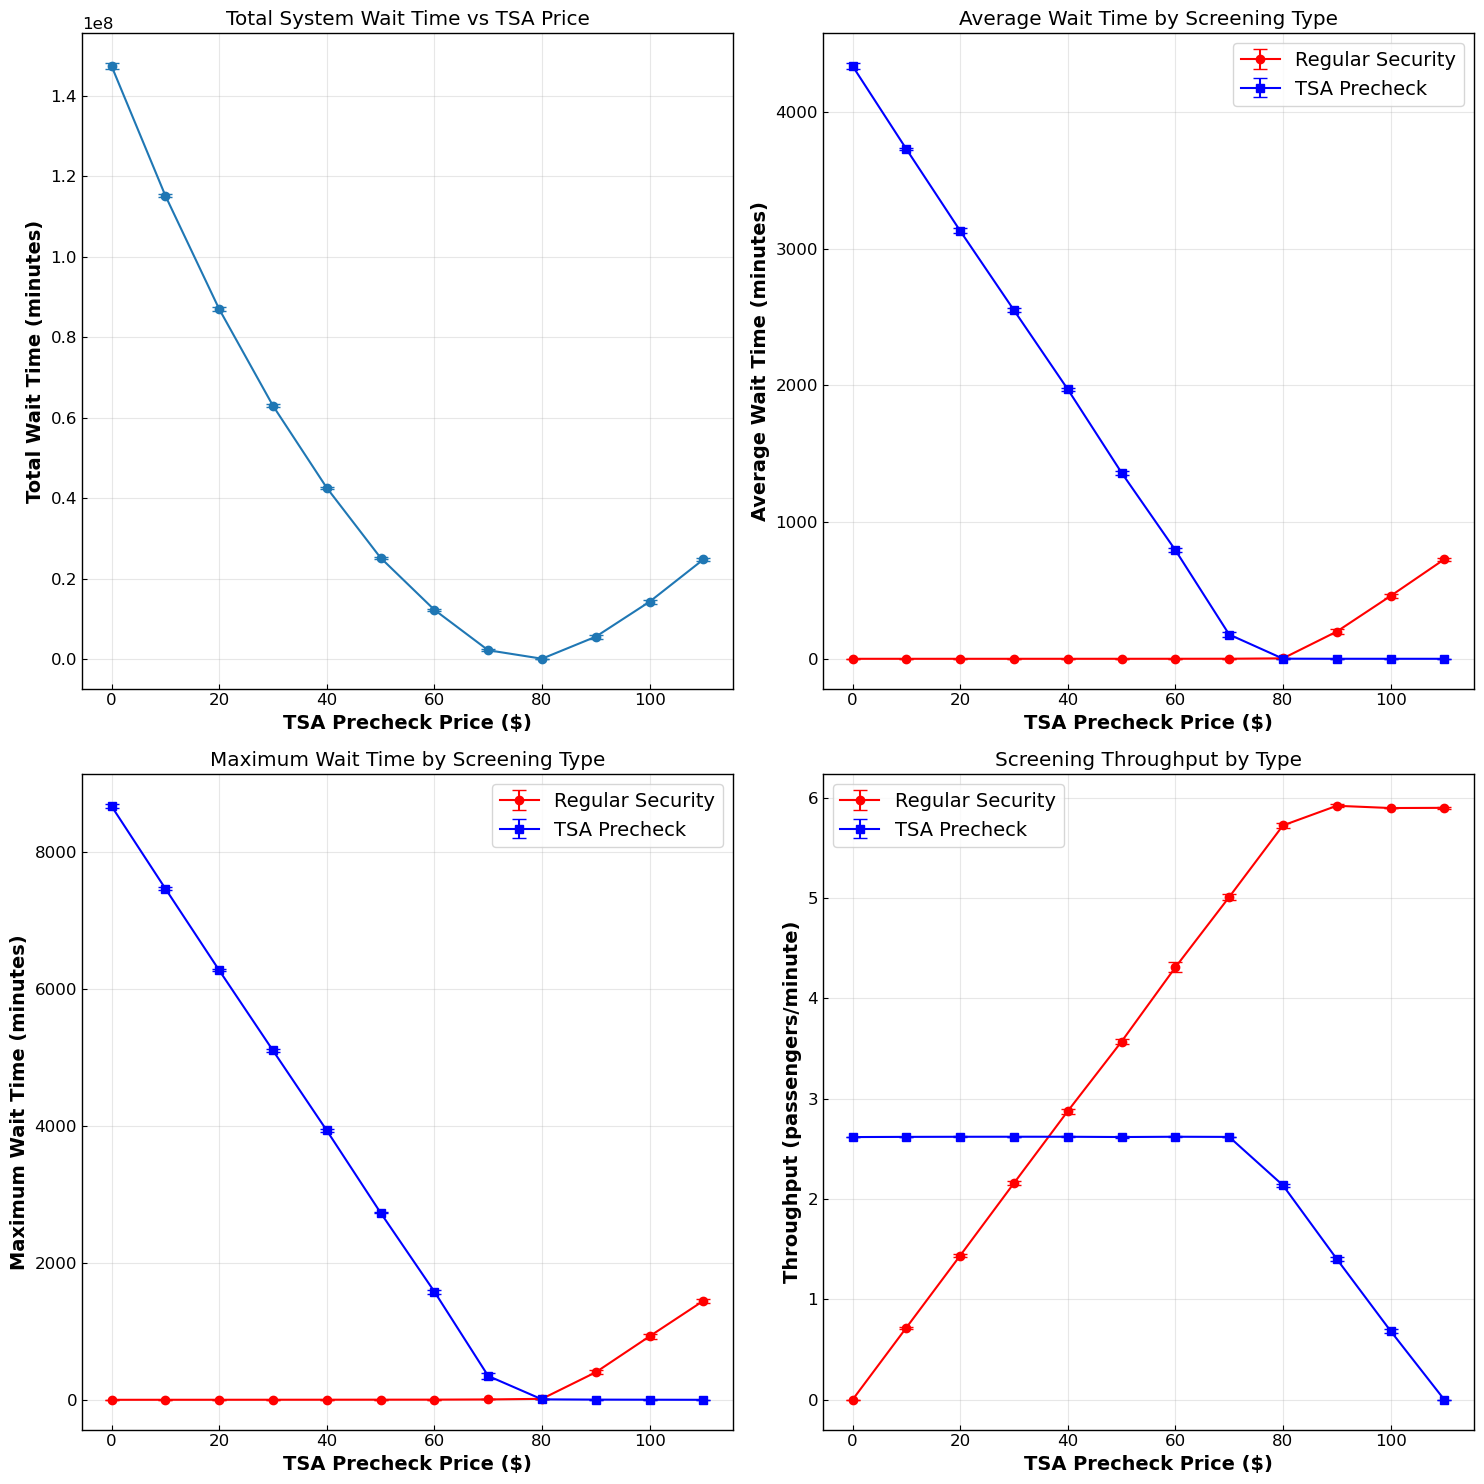

In [62]:
# Set seed for reproduceability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(0, 120, 10)  # Test prices from $0 to $110 in $10 increments
customer_count = int(MAX_CUST)

service_params = {
    "regular_mean": SERVICE_TIME_REGULAR_SECURITY,
    "regular_std": SERVICE_TIME_REGULAR_SECURITY_STD,
    "precheck_mean": SERVICE_TIME_PSA_PRECHECK,
    "precheck_std": SERVICE_TIME_PSA_PRECHECK_STD,
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5,  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(
    results[
        ["price", "precheck_percentage", "total_wait_time_mean", "avg_wait_time_mean"]
    ].round(3)
)

# Find optimal price (minimum total wait time)
optimal_idx = results["total_wait_time_mean"].idxmin()
optimal_price = results.loc[optimal_idx, "price"]
optimal_wait_time = results.loc[optimal_idx, "total_wait_time_mean"]

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(
    f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%"
)

# Create visualizations
plot_results(results)

- Now we know that the optimal price is in the range 70 to 90, so we tighten our price range and lower the increment to $0.25 to evaluate.

Running TSA cost analysis...
Testing price: $70.0
Testing price: $70.25
Testing price: $70.5
Testing price: $70.75
Testing price: $71.0
Testing price: $71.25
Testing price: $71.5
Testing price: $71.75
Testing price: $72.0
Testing price: $72.25
Testing price: $72.5
Testing price: $72.75
Testing price: $73.0
Testing price: $73.25
Testing price: $73.5
Testing price: $73.75
Testing price: $74.0
Testing price: $74.25
Testing price: $74.5
Testing price: $74.75
Testing price: $75.0
Testing price: $75.25
Testing price: $75.5
Testing price: $75.75
Testing price: $76.0
Testing price: $76.25
Testing price: $76.5
Testing price: $76.75
Testing price: $77.0
Testing price: $77.25
Testing price: $77.5
Testing price: $77.75
Testing price: $78.0
Testing price: $78.25
Testing price: $78.5
Testing price: $78.75
Testing price: $79.0
Testing price: $79.25
Testing price: $79.5
Testing price: $79.75
Testing price: $80.0
Testing price: $80.25
Testing price: $80.5
Testing price: $80.75
Testing price: $81.0
Test

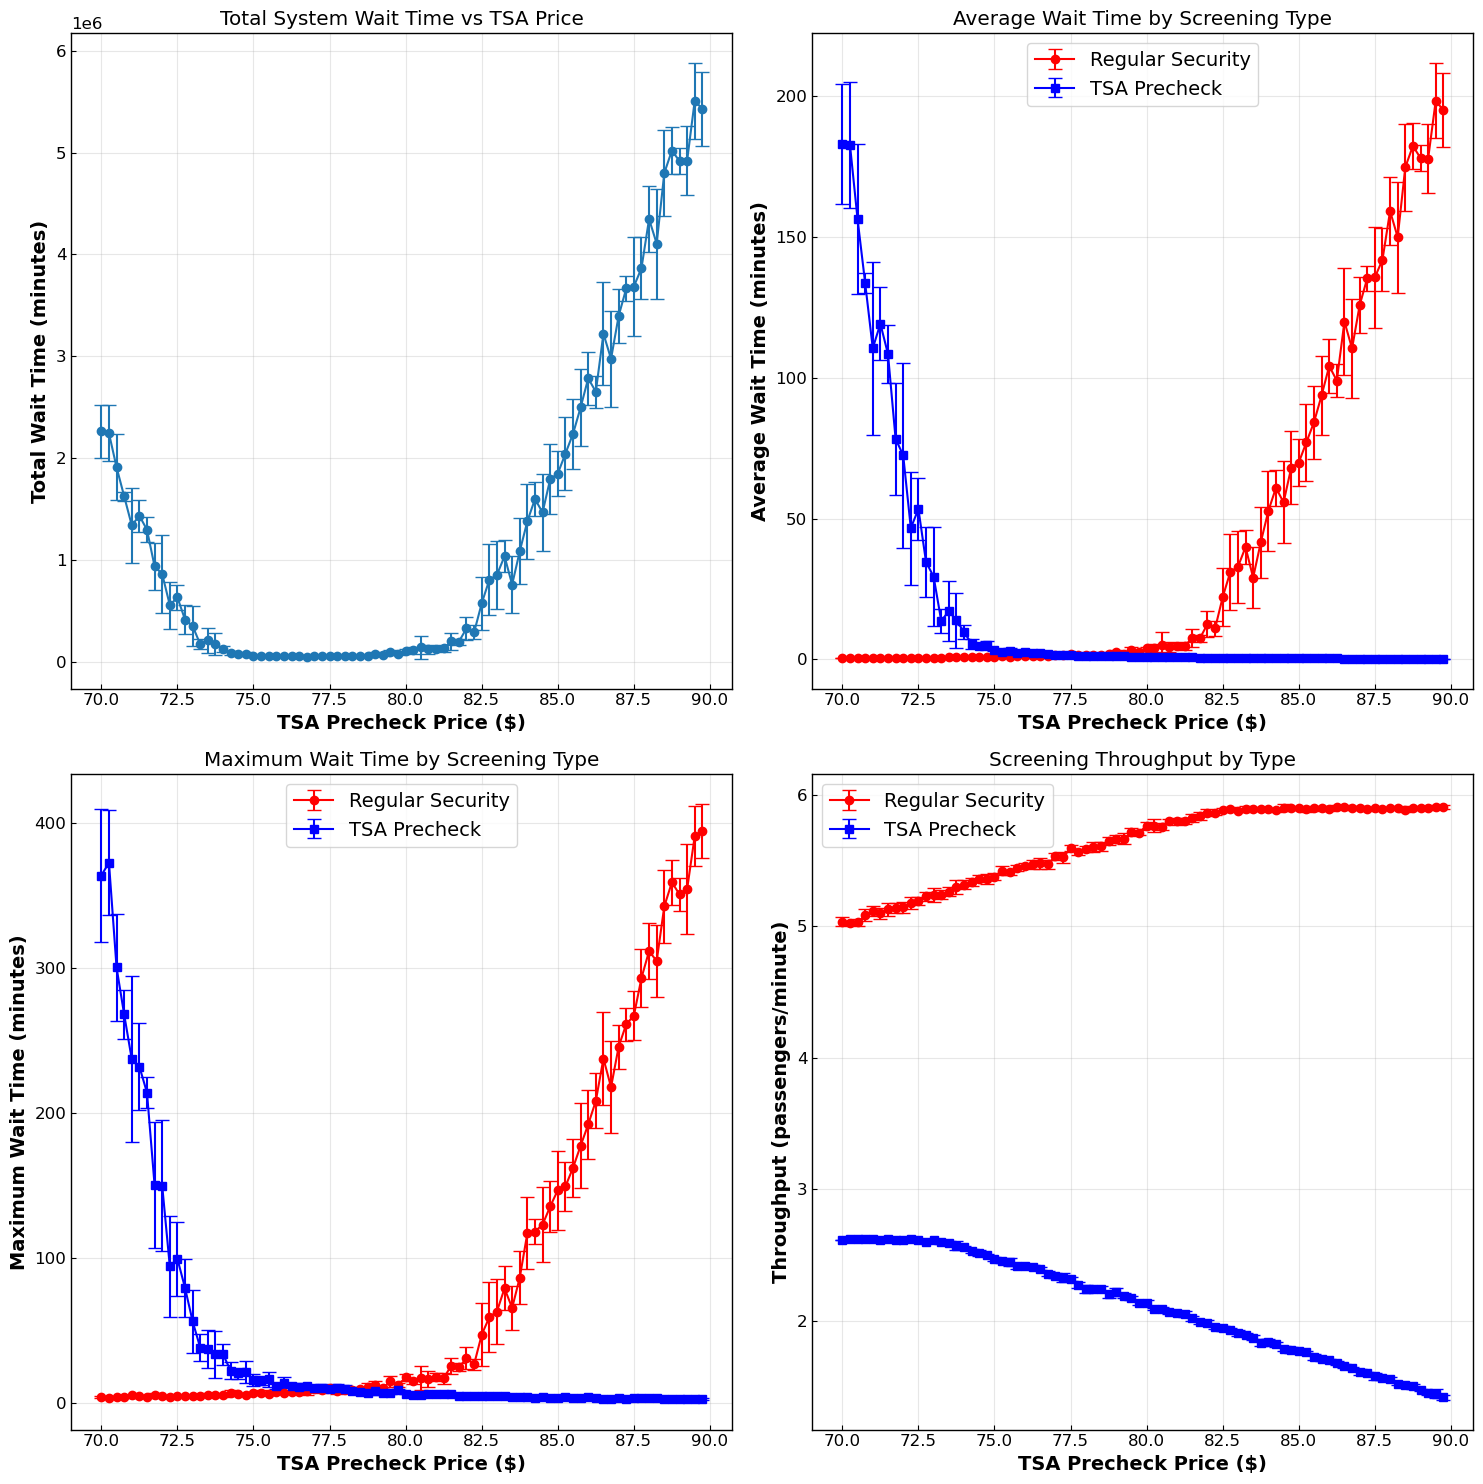

In [63]:
# Putting in Seed value for repeatability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(70, 90, 0.25)  # Test prices from $0 to $110 in $10 increments
customer_count = int(MAX_CUST)

service_params = {
    "regular_mean": SERVICE_TIME_REGULAR_SECURITY,
    "regular_std": SERVICE_TIME_REGULAR_SECURITY_STD,
    "precheck_mean": SERVICE_TIME_PSA_PRECHECK,
    "precheck_std": SERVICE_TIME_PSA_PRECHECK_STD,
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5,  # Run 10 simulations per price point
)

# Display results
print("\nResults Summary:")
print(
    results[
        ["price", "precheck_percentage", "total_wait_time_mean", "avg_wait_time_mean"]
    ].round(3)
)

# Find optimal price (minimum total wait time)
optimal_idx = results["total_wait_time_mean"].idxmin()
optimal_price = results.loc[optimal_idx, "price"]
optimal_wait_time = results.loc[optimal_idx, "total_wait_time_mean"]

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(
    f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%"
)

# Create visualizations
plot_results(results)

After iterating through this a couple of times without a seed, the values fluctuate between 76.25 and 77.25.  This is due to the probabilistic nature of the model.  The midpoint of this is $76.75, which turns out to be the current TSA cost.  With the seed selected, this is the value that we observe.


In [64]:
# Putting in seed value for repeatability.
np.random.seed(100)


# Define test parameters
price_range = [76.75]

service_params = {
    "regular_mean": SERVICE_TIME_REGULAR_SECURITY,
    "regular_std": SERVICE_TIME_REGULAR_SECURITY_STD,
    "precheck_mean": SERVICE_TIME_PSA_PRECHECK,
    "precheck_std": SERVICE_TIME_PSA_PRECHECK_STD,
}

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=MAX_CUST,
    service_params=service_params,
    arrival_rate=SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE,
    num_simulations=500,  # Run 500 simulations per price point
)

print(results)

Running TSA cost analysis...
Testing price: $76.75
   price  precheck_percentage  total_wait_time_mean  total_wait_time_std  \
0  76.75                  0.3          49200.571243          5536.498094   

   avg_wait_time_mean  avg_wait_time_std  standard_customers_mean  \
0            1.447118           0.162843                  23799.0   

   precheck_customers_mean  avg_wait_standard_mean  avg_wait_standard_std  \
0                  10200.0                1.288497               0.202373   

   avg_wait_precheck_mean  avg_wait_precheck_std  max_wait_standard_mean  \
0                1.817219               0.266484                8.294574   

   max_wait_standard_std  max_wait_precheck_mean  max_wait_precheck_std  \
0               1.857322               11.225911               2.351299   

   throughput_standard_mean  throughput_standard_std  \
0                   5.50288                 0.035486   

   throughput_precheck_mean  throughput_precheck_std  
0                  2.357172   

In [65]:
print(
    "Average Wait Time Standard Screening: "
    + str(results["avg_wait_standard_mean"].values[0])
)
print(
    "Average Wait Time PreCheck Screening: "
    + str(results["avg_wait_precheck_mean"].values[0])
)
print(
    "Average Max Wait Time Standard Screening: "
    + str(results["max_wait_standard_mean"].values[0])
)
print(
    "Average Max Wait Time PreCheck Screening: "
    + str(results["max_wait_precheck_mean"].values[0])
)
print(
    "Average Throughput Standard Screening: "
    + str(results["throughput_standard_mean"].values[0])
)
print(
    "Average Throughput Standard Screening per Server: "
    + str(results["throughput_standard_mean"].values[0] / 3)
)
print(
    "Average Throughput PreCheck Screening: "
    + str(results["throughput_precheck_mean"].values[0])
)

Average Wait Time Standard Screening: 1.288496894202561
Average Wait Time PreCheck Screening: 1.817218986098972
Average Max Wait Time Standard Screening: 8.29457376575208
Average Max Wait Time PreCheck Screening: 11.225911085142576
Average Throughput Standard Screening: 5.50288049250012
Average Throughput Standard Screening per Server: 1.83429349750004
Average Throughput PreCheck Screening: 2.3571720226079416


- These results are counterintuitive, as we would expect the PreCheck line to have lower average wait times and lower maximum wait times.  
- We attribute this to the server distribution, creating a bottleneck for the PreCheck.  
- Although the Standard Screening Throughput is higher, when evaluated on a per-server basis, we observe a higher rate for the PreCheck Lane than for the standard screening lane.


### Experiment: 70% TSA PreCheck Participation

- Now, let's investigate what would happen if the participation percentage increases to 70%.  From the demand model, we know that 70% occurs at approximately $32.89.


In [66]:
print(round(Precheck_Customers__Percentage_By_Price(32.892), 2))

0.7


In [67]:
# Putting in Seed value for repeatability.
np.random.seed(100)

customer_count = 34000

# Define test parameters
price_range = [32.89]

service_params = {
    "regular_mean": SERVICE_TIME_REGULAR_SECURITY,
    "regular_std": SERVICE_TIME_REGULAR_SECURITY_STD,
    "precheck_mean": SERVICE_TIME_PSA_PRECHECK,
    "precheck_std": SERVICE_TIME_PSA_PRECHECK_STD,
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=500,  # Run 500 simulations per price point
)

print(results)

Running TSA cost analysis...
Testing price: $32.89
   price  precheck_percentage  total_wait_time_mean  total_wait_time_std  \
0  32.89             0.700026          5.668803e+07        448732.013687   

   avg_wait_time_mean  avg_wait_time_std  standard_customers_mean  \
0         1667.343998          13.198389                  10199.0   

   precheck_customers_mean  avg_wait_standard_mean  avg_wait_standard_std  \
0                  23800.0                 0.02562               0.001774   

   avg_wait_precheck_mean  avg_wait_precheck_std  max_wait_standard_mean  \
0             2381.838962              18.854226                0.992761   

   max_wait_standard_std  max_wait_precheck_mean  max_wait_precheck_std  \
0               0.150854             4763.069417              32.538446   

   throughput_standard_mean  throughput_standard_std  \
0                  2.358621                 0.023755   

   throughput_precheck_mean  throughput_precheck_std  
0                  2.620386   

In [68]:
print(
    "Average Wait Time Standard Screening: "
    + str(results["avg_wait_standard_mean"].values[0])
)
print(
    "Average Wait Time PreCheck Screening: "
    + str(results["avg_wait_precheck_mean"].values[0])
)
print(
    "Average Max Wait Time Standard Screening: "
    + str(results["max_wait_standard_mean"].values[0])
)
print(
    "Average Max Wait Time PreCheck Screening: "
    + str(results["max_wait_precheck_mean"].values[0])
)
print(
    "Average Throughput Standard Screening: "
    + str(results["throughput_standard_mean"].values[0])
)
print(
    "Average Throughput Standard Screening per Server: "
    + str(results["throughput_standard_mean"].values[0] / 3)
)
print(
    "Average Throughput PreCheck Screening: "
    + str(results["throughput_precheck_mean"].values[0])
)

Average Wait Time Standard Screening: 0.025620176747462992
Average Wait Time PreCheck Screening: 2381.8389622704135
Average Max Wait Time Standard Screening: 0.9927608936849152
Average Max Wait Time PreCheck Screening: 4763.06941682276
Average Throughput Standard Screening: 2.3586212909100768
Average Throughput Standard Screening per Server: 0.7862070969700256
Average Throughput PreCheck Screening: 2.6203862764294654


- From this evaluation, we see that this leads to an unrealistic model.  The average TSA PreCheck passenger will wait 2381 minutes, or 1.65 days in line.  This is an inefficient use of resources and not a sustainable approach.

## M/N/c 2 Regular Lines, 2 PreCheck Lines

- Now we reconfigure so that the servers are split evenly between the two screening types.  We use the "run_cost_anlysis_split_lanes" function to do this evaluation.

Running TSA cost analysis...
Testing price: $0
Testing price: $10
Testing price: $20
Testing price: $30
Testing price: $40
Testing price: $50
Testing price: $60
Testing price: $70
Testing price: $80
Testing price: $90
Testing price: $100
Testing price: $110

Results Summary:
    price  precheck_percentage  total_wait_time_mean  avg_wait_time_mean  \
0       0                1.000          3.708220e+07            1090.653   
1      10                0.909          2.415487e+07             710.458   
2      20                0.818          1.334013e+07             392.368   
3      30                0.726          4.847019e+06             142.564   
4      40                0.635          5.012468e+04               1.474   
5      50                0.544          3.100121e+04               0.912   
6      60                0.453          3.741566e+06             110.049   
7      70                0.362          1.277125e+07             375.636   
8      80                0.270          

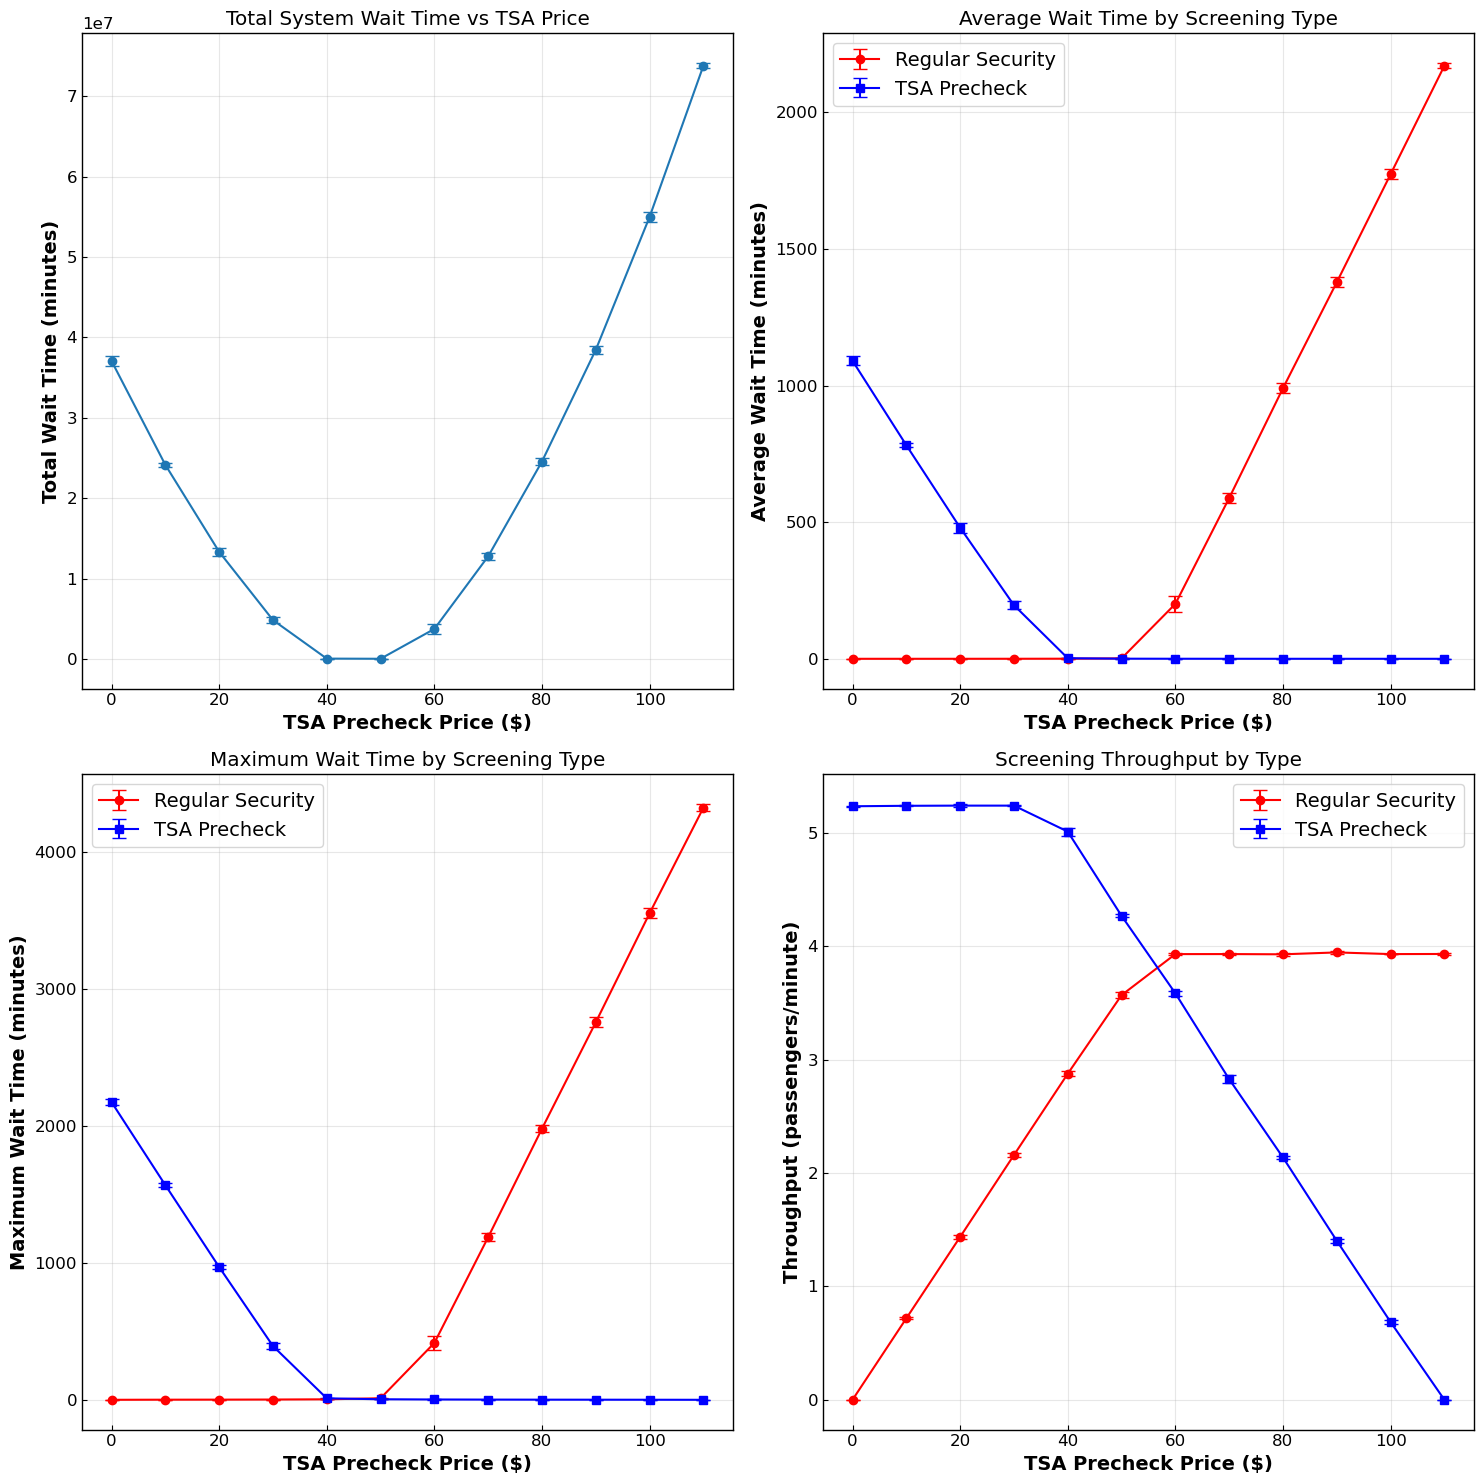

In [70]:
# Putting in seed value for repeatability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(0, 120, 10)  # Test prices from $0 to $110 in $10 increments

service_params = {
    "regular_mean": SERVICE_TIME_REGULAR_SECURITY,
    "regular_std": SERVICE_TIME_REGULAR_SECURITY_STD,
    "precheck_mean": SERVICE_TIME_PSA_PRECHECK,
    "precheck_std": SERVICE_TIME_PSA_PRECHECK_STD,
}

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis_split_lanes(
    price_range=price_range,
    customer_count=int(MAX_CUST),
    service_params=service_params,
    arrival_rate=SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE,
    num_simulations=5,  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(
    results[
        [
            "price",
            "precheck_percentage",
            "total_wait_time_mean",
            "avg_wait_time_mean",
            "avg_wait_standard_mean",
            "avg_wait_precheck_mean",
            "throughput_standard_mean",
            "throughput_precheck_mean",
        ]
    ].round(3)
)

# Find optimal price (minimum total wait time)
optimal_idx = results["total_wait_time_mean"].idxmin()
optimal_price = results.loc[optimal_idx, "price"]
optimal_wait_time = results.loc[optimal_idx, "total_wait_time_mean"]

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(
    f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%"
)

# Create visualizations
plot_results(results)

- From this initial price range, we see that the points of interest are between the high 30s and the low 50s, so we tighten the range and lower the step size to 0.25.


Running TSA cost analysis...
Testing price: $38.0
Testing price: $38.25
Testing price: $38.5
Testing price: $38.75
Testing price: $39.0
Testing price: $39.25
Testing price: $39.5
Testing price: $39.75
Testing price: $40.0
Testing price: $40.25
Testing price: $40.5
Testing price: $40.75
Testing price: $41.0
Testing price: $41.25
Testing price: $41.5
Testing price: $41.75
Testing price: $42.0
Testing price: $42.25
Testing price: $42.5
Testing price: $42.75
Testing price: $43.0
Testing price: $43.25
Testing price: $43.5
Testing price: $43.75
Testing price: $44.0
Testing price: $44.25
Testing price: $44.5
Testing price: $44.75
Testing price: $45.0
Testing price: $45.25
Testing price: $45.5
Testing price: $45.75
Testing price: $46.0
Testing price: $46.25
Testing price: $46.5
Testing price: $46.75
Testing price: $47.0
Testing price: $47.25
Testing price: $47.5
Testing price: $47.75
Testing price: $48.0
Testing price: $48.25
Testing price: $48.5
Testing price: $48.75
Testing price: $49.0
Test

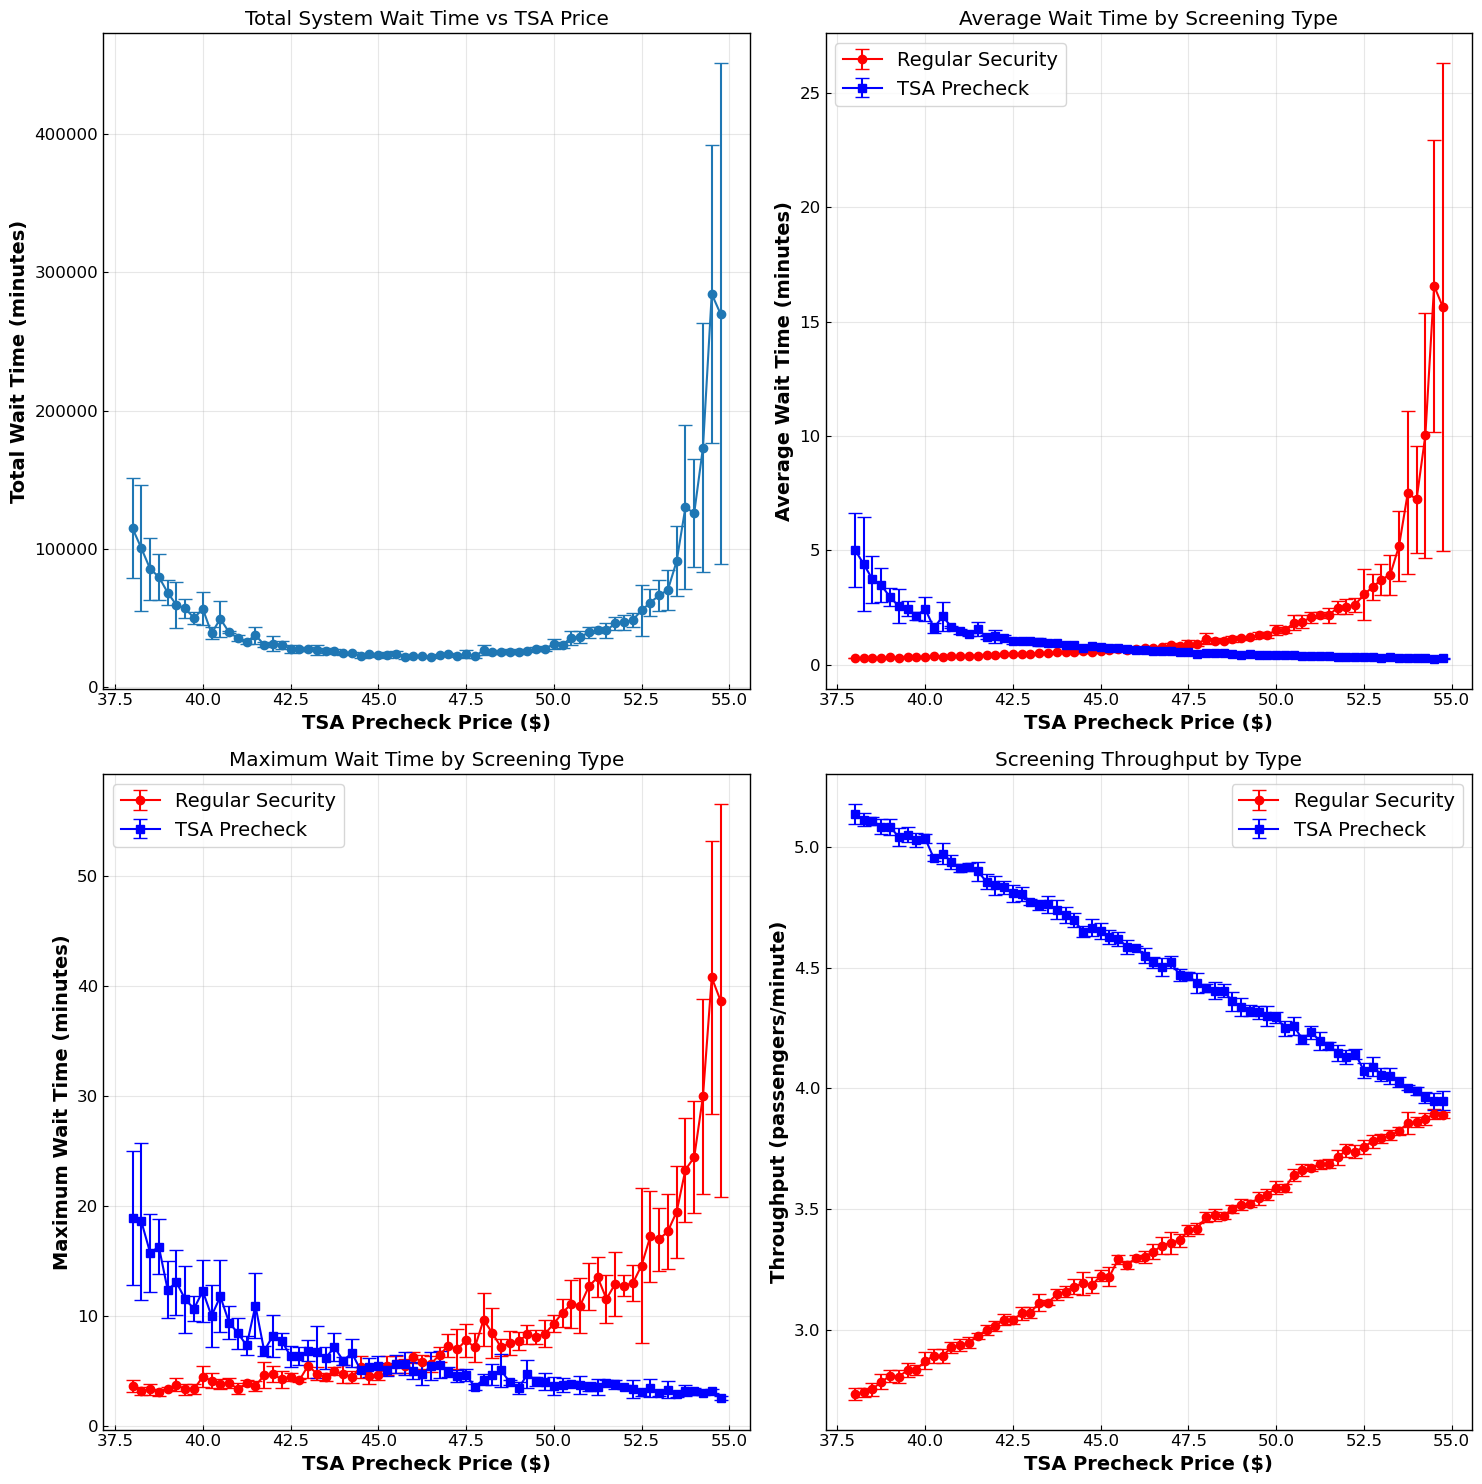

In [71]:
# Putting in seed value for repeatability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(38, 55, 0.25)  # Test prices from $0 to $110 in $10 increments

service_params = {
    "regular_mean": SERVICE_TIME_REGULAR_SECURITY,
    "regular_std": SERVICE_TIME_REGULAR_SECURITY_STD,
    "precheck_mean": SERVICE_TIME_PSA_PRECHECK,
    "precheck_std": SERVICE_TIME_PSA_PRECHECK_STD,
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis_split_lanes(
    price_range=price_range,
    customer_count=int(MAX_CUST),
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5,  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(
    results[
        [
            "price",
            "precheck_percentage",
            "total_wait_time_mean",
            "avg_wait_time_mean",
            "avg_wait_standard_mean",
            "avg_wait_precheck_mean",
            "throughput_standard_mean",
            "throughput_precheck_mean",
        ]
    ].round(3)
)

# Find optimal price (minimum total wait time)
optimal_idx = results["total_wait_time_mean"].idxmin()
optimal_price = results.loc[optimal_idx, "price"]
optimal_wait_time = results.loc[optimal_idx, "total_wait_time_mean"]

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(
    f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%"
)

# Create visualizations
plot_results(results)

- We observe that the optimal TSA price is at $46.50.  With that information, we rerun the evaluation to find statistics on this price scenario.

In [72]:
# Putting in seed value for repeatability.
np.random.seed(100)


# Define test parameters
price_range = [46.5]

service_params = {
    "regular_mean": SERVICE_TIME_REGULAR_SECURITY,
    "regular_std": SERVICE_TIME_REGULAR_SECURITY_STD,
    "precheck_mean": SERVICE_TIME_PSA_PRECHECK,
    "precheck_std": SERVICE_TIME_PSA_PRECHECK_STD,
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis_split_lanes(
    price_range=price_range,
    customer_count=int(MAX_CUST),
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=500,  # Run 500 simulations per price point
)

print(results)

Running TSA cost analysis...
Testing price: $46.5
   price  precheck_percentage  total_wait_time_mean  total_wait_time_std  \
0   46.5             0.575896          22892.629034          1469.106276   

   avg_wait_time_mean  avg_wait_time_std  standard_customers_mean  \
0            0.673332            0.04321                  14419.0   

   precheck_customers_mean  avg_wait_standard_mean  avg_wait_standard_std  \
0                  19580.0                0.756697               0.074234   

   avg_wait_precheck_mean  avg_wait_precheck_std  max_wait_standard_mean  \
0                0.611942               0.050961                6.179261   

   max_wait_standard_std  max_wait_precheck_mean  max_wait_precheck_std  \
0                1.21667                 4.95802               0.912415   

   throughput_standard_mean  throughput_standard_std  \
0                  3.333978                 0.027936   

   throughput_precheck_mean  throughput_precheck_std  
0                  4.531705    

In [73]:
print(
    "Average Wait Time Standard Screening: "
    + str(results["avg_wait_standard_mean"].values[0])
)
print(
    "Average Wait Time PreCheck Screening: "
    + str(results["avg_wait_precheck_mean"].values[0])
)
print(
    "Average Max Wait Time Standard Screening: "
    + str(results["max_wait_standard_mean"].values[0])
)
print(
    "Average Max Wait Time PreCheck Screening: "
    + str(results["max_wait_precheck_mean"].values[0])
)
print(
    "Average Throughput Standard Screening: "
    + str(results["throughput_standard_mean"].values[0])
)
print(
    "Average Throughput Standard Screening per Server: "
    + str(results["throughput_standard_mean"].values[0] / 2)
)
print(
    "Average Throughput PreCheck Screening: "
    + str(results["throughput_precheck_mean"].values[0])
)
print(
    "Average Throughput Standard Screening per Server: "
    + str(results["throughput_precheck_mean"].values[0] / 2)
)

Average Wait Time Standard Screening: 0.7566966043883053
Average Wait Time PreCheck Screening: 0.6119418128537361
Average Max Wait Time Standard Screening: 6.179260791633471
Average Max Wait Time PreCheck Screening: 4.958020122419834
Average Throughput Standard Screening: 3.333978167653086
Average Throughput Standard Screening per Server: 1.666989083826543
Average Throughput PreCheck Screening: 4.531704593970162
Average Throughput Standard Screening per Server: 2.265852296985081


- From the above simulations, we see a large wait time improvement in the system performance when more individuals are utilizing PreCheck Screening and the screening servers are redistributed to a 50-50 split.  This is an intuitive result that meets our expectations, as the higher PreCheck service rate with equal server count shows the expected lower average wait time, lower max wait time, and higher throughput.
